# Peers given the formula's symbols copy its errors — Candidate-Signature Consensus (CSC), T6-E

This notebook is a runnable walkthrough of the **T6-E experiment** (iteration 4, development set E). The experiment builds and tests a *gold-free* error score for natural-language → first-order-logic (NL→FOL) translations.

**What CSC measures.** Take a sentence `text` and a candidate formula `fol`. Three cheap peer LLMs from vendor families *other than the candidate's* (DeepSeek-V3.2, Phi-4, GPT-4.1-mini, Qwen3-235B) translate `text`. They get the dataset-E few-shot prompt **plus the candidate's own predicate/constant symbol list**. Then

```
c_csc(x) = 1 − (share of parseable family-disjoint peers whose formula is z3-equivalent to x.fol,
               symbols identified by lowercased name + arity; no aligner)
```

Higher values mean the candidate is more likely to be an **ERROR**. The hope was that sharing the vocabulary would stop peers from disagreeing only because they chose different names. **The result is negative:** peers that see the candidate's symbols also *copy its errors* (anchoring).
- On the full PRIMARY set (354 rows), CSC lowers false alarms on CORRECT rows: d = 0.139 vs 0.323 for the same peers without the signature.
- But it raises the endorsement of ERROR rows: e = 0.459 vs 0.173.
- Its stratified AUROC falls to 0.614, against 0.770 for signature-free exact consensus.

**What this notebook does.**
- The original artifact is a multi-stage pipeline (`method.py` → `src/*.py`), and its paid LLM stages have already run. This demo loads a 100-row stratified subset of the PRIMARY rows **with the cached peer generations** (no API calls).
- It then re-runs the $0 stages: **score** (z3 consensus scoring, `src/csc.py`) and **analyse** (e/d decomposition, stratified AUROC, sentence-cluster bootstrap).
- The code is the original code: `method.py`, `src/csc.py`, `src/score.py::score_task` and `vendor/ev2/stats.py`. It is split into cells, with explanations between them.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, scipy, pandas, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

## Imports

The first block is `method.py`'s import block, unchanged. The second block adds what this notebook needs for the in-notebook stages and the plots.

In [2]:
# --- method.py imports (original) ---
import os
import resource
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- additional imports for the notebook (stage bodies from src/score.py, src/analyse.py + plots) ---
import json
import time
import types
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load the demo data

`mini_demo_data.json` contains:
- **100 PRIMARY R_AB rows** of dataset E, stratified by stratum (L25 / L20 / EXC / CTRL) × label (seed 0);
- per row, the **3 cached CSC peer generations** (peers were shown the candidate's symbol list) and the **3 FREE-MATCHED peer generations** (the same families' ordinary few-shot outputs, with no symbol list);
- the pipeline's own scores (`c_csc`, `c_free_exact`, `c_score_align`, the flash-lite judge), used as reference columns;
- the few-shot prompt `fewshot_v1` that the peers received.

The loader fetches the file from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-4/experiment-9/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["examples"]), "rows;", data["description"][:160], "...")

100 rows; Demo subset of T6-E Candidate-Signature Consensus (CSC): 100 PRIMARY R_AB rows of development set E (stratified by stratum x label, seed 0). Each row has the ca ...


## Configuration

These are all the tunable parameters. The original run scored **all 354 PRIMARY rows** (2,686 rows for the FREE arm) and used **B = 2000** sentence-cluster bootstrap resamples. The demo uses a subset so that it finishes within a few minutes.

In [5]:
N_ROWS = 100          # rows of the demo subset to score (max 100 in mini_demo_data.json; original: 354 PRIMARY rows)
N_BOOT = 2000         # sentence-cluster bootstrap resamples (original: B_DEFAULT = 2000)
Z3_TIMEOUT_MS = 2000  # z3 timeout per equivalence check (original: 2000 ms; UNKNOWN counts as NOT equivalent)
GRADED = True         # also compute c_csc_graded (claim-unit F1, identity map) -- original: True
FLAG_THRESHOLD = 0.5  # binary endorsement: endorsed iff c <= 0.5 (original, src/analyse.py)

## `method.py`: the pipeline entry point

`method.py` is a **stage runner**. Each stage is a separate script under `src/`, launched as a subprocess with `PYTHONHASHSEED=0`:

| stage | what it does | cost |
|---|---|---|
| prep / pilot / prereg / mini / full | integrity checks, pilot, pre-registration, paid peer generation (OpenRouter, disk-cached) | paid |
| repro | reproduces eval 2's pool AUROC (0.7427) | $0 |
| **score** | label-blind z3 scoring of every arm (`src/score.py` → `src/csc.py`) | $0 |
| **analyse** | e/d decomposition, stratified AUROC, bootstrap, gates (`src/analyse.py`) | $0 |
| posthoc / audit / report | leakage sensitivity, independent re-derivation, tables | $0 |

The cell below is `method.py`'s configuration and `main()`, unchanged except for two notebook fixes:
- `ROOT` becomes the working directory, because `__file__` does not exist in a notebook.
- The log file goes to `logs/method.log` under that directory.

The `src/*.py` stage scripts need the full 2,686-row frame and are not shipped with this demo. The **score** and **analyse** stage bodies are reproduced as notebook cells further down, and `main()` is called on them at the end of the processing section.

In [6]:
ROOT = Path.cwd()  # notebook: original is Path(__file__).resolve().parent
STAGES = {"prep": ["src/prep.py"], "pilot": ["src/pilot.py"], "prereg": ["src/gen.py", "prereg"], "mini": ["src/gen.py", "mini"],
          "full": ["src/gen.py", "full"], "repro": ["src/repro.py"], "score": ["src/score.py"], "analyse": ["src/analyse.py"],
          "posthoc": ["src/posthoc_contam.py"], "report": ["src/report.py"], "audit": ["src/audit_rederive.py"], "audit_extra": ["src/audit_rederive.py", "extra"], "test": ["-m", "pytest", "-q", "-c", "pytest.ini", "tests"]}

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")


@logger.catch(reraise=True)
def main(stages: list[str]) -> None:
    ram = 20 * 1024**3  # container limit 29 GB; the heaviest stage (analysis bootstrap) needs < 4 GB
    resource.setrlimit(resource.RLIMIT_AS, (ram, ram))
    env = {**os.environ, "PYTHONHASHSEED": "0"}  # repair_census.fp uses hash()
    for st in stages:
        if st not in STAGES:
            raise ValueError(f"unknown stage {st}; choose from {list(STAGES)}")
        logger.info(f"=== stage {st}")
        r = subprocess.run([sys.executable, *STAGES[st]], cwd=ROOT, env=env)
        if r.returncode != 0:
            raise RuntimeError(f"stage {st} failed with exit code {r.returncode}")
    logger.info("done")

## Vendored dependencies (read-only copies, unchanged)

`src/csc.py` builds on code from earlier experiments that the artifact vendors under `vendor/`:
- `vendor/e8src/vendor_e/fol.py`: the dataset-E FOL parser and the z3 encoding, with `parse(...)` and `equivalent(...)`.
- `vendor/e8src/vendor_c/repair_census.py`: symbol extraction (`symbols`), a random-finite-model fingerprint (`fp`) used as a cheap non-equivalence filter, and the typed-repair search (`search`).
- `vendor/e8src/peer_text.py`: `parse_fol`, alpha-normalised `canon`, claim units, the `Entailer` and `graded_consensus`.
- `vendor/ev2/stats.py`: tie-aware AUROC, stratified AUROC and the sentence-cluster bootstrap.

The cells below write these files **byte-for-byte** to the same relative paths, so the original imports work unchanged. They are long; you can skim or collapse them.

In [7]:
# %%writefile does not create directories; also write the few-shot prompt that csc.build_prompt reads
for d in ('vendor/e8src/vendor_e', 'vendor/e8src/vendor_c', 'vendor/ev2', 'vendor/data/prompts', 'src'):
    os.makedirs(d, exist_ok=True)
Path('vendor/data/prompts/fewshot_v1.txt').write_text(json.dumps(data['fewshot_prompt'], ensure_ascii=False, indent=1))
print('prompt written to vendor/data/prompts/fewshot_v1.txt;', len(data['fewshot_prompt']['exemplars']), 'exemplar messages')

prompt written to vendor/data/prompts/fewshot_v1.txt; 12 exemplar messages


In [8]:
%%writefile vendor/e8src/vendor_e/fol.py
"""Unicode FOL (FOLIO/MALLS notation) -> AST -> z3; semantic monotonicity profile per predicate.

Grammar (lowest to highest precedence): ↔  <  →  <  ∨ / ⊕  <  ∧  <  ¬, quantifiers, atoms.
A quantifier binds the immediately following parenthesised group, atom, negation or quantifier
(FOLIO/MALLS convention: '∀x (A(x)) ∧ ∀y (B(y))' is two sentences).
"""
import re
import z3

TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def profile(e, ms=3000):
    """Semantic monotonicity of formula e in each predicate: UP / DOWN / VACUOUS / NONMONO / UNKNOWN."""
    ar = preds(e)
    base = {q: mkpred(q, m) for q, m in ar.items()}
    out = {}
    for p, n in ar.items():
        alt = dict(base)
        alt[p] = mkpred(p + "_prime", n)
        xs = [z3.Const(f"_x{i}", U) for i in range(n)]
        sub = z3.ForAll(xs, z3.Implies(base[p](*xs), alt[p](*xs))) if n else z3.Implies(base[p], alt[p])
        F, Fp = to_z3(e, {}, base), to_z3(e, {}, alt)
        up, down = valid(z3.Implies(z3.And(sub, F), Fp), ms), valid(z3.Implies(z3.And(sub, Fp), F), ms)
        if up is None or down is None:
            out[p] = "UNKNOWN"
        else:
            out[p] = {(True, True): "VACUOUS", (True, False): "UP", (False, True): "DOWN", (False, False): "NONMONO"}[(up, down)]
    return out


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)


def connectivity_flags(e):
    """Binding check: inside each quantifier scope, variables must be linked through shared atoms.
    Returns list of variables that are quantified but share no atom with any other variable in the
    same top-level sentence while other variables exist (an 'island')."""
    atoms = []

    def walk(x):
        if x[0] == "atom":
            atoms.append(set(a for a in x[2]))
        elif x[0] in ("all", "ex"):
            walk(x[2])
        elif x[0] == "not":
            walk(x[1])
        else:
            walk(x[1]); walk(x[2])

    def qvars(x, acc):
        if x[0] in ("all", "ex"):
            acc.append(x[1]); qvars(x[2], acc)
        elif x[0] == "not":
            qvars(x[1], acc)
        elif x[0] != "atom":
            qvars(x[1], acc); qvars(x[2], acc)
        return acc

    walk(e)
    vs = qvars(e, [])
    if len(vs) < 2:
        return []
    # union-find over variables via atoms
    parent = {v: v for v in vs}

    def f(v):
        while parent[v] != v:
            v = parent[v]
        return v
    for a in atoms:
        a = [v for v in a if v in parent]
        for v in a[1:]:
            parent[f(v)] = f(a[0])
    comps = {}
    for v in vs:
        comps.setdefault(f(v), []).append(v)
    if len(comps) == 1:
        return []
    main = max(comps.values(), key=len)
    return [v for c in comps.values() if c is not main for v in c]


def prenex_blocks(e):
    """Split a formula into top-level conjuncts; for each, collect its leading quantifier block."""
    parts = []

    def flat(x):
        if x[0] == "and":
            flat(x[1]); flat(x[2])
        else:
            parts.append(x)
    flat(e)
    return parts


def coupled_independent_vars(e):
    """GLUE check: within ONE top-level conjunct, >=2 universally quantified variables that never
    co-occur in any atom, i.e. independent generic claims wrongly bundled under a joint quantifier
    ('∀x∀y (Wolf(x) ∧ Bird(y) → Howls(x) ∧ Chirps(y))'). Returns True if any conjunct has one."""
    for part in prenex_blocks(e):
        if connectivity_flags(part):
            return True
    return False


def token_profile(prof):
    """Project a predicate-level polarity profile onto CamelCase word tokens, so that merged
    (WorksInNewsIndustryAndReportsOnEvents) and split (WorksInNewsIndustry ∧ ReportsOnEvents)
    renderings of the same concept get the same profile."""
    import re as _re
    STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from"}
    out = {}
    for key, pol in prof.items():
        name = key.split("/")[0]
        for w in _re.findall(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+", name):
            w = w.lower()
            if w in STOP:
                continue
            w = w[:-1] if w.endswith("s") and len(w) > 3 else w
            out.setdefault(w, set()).add(pol)
    return out

Overwriting vendor/e8src/vendor_e/fol.py


In [9]:
%%writefile vendor/e8src/vendor_c/repair_census.py
"""MINIMAL-TYPED-REPAIR census of real NL->FOL errors (review critique 1 & 2 of iter 2).

For every curated FOLIO-conclusion / MALLS-test item whose ORIGINAL gold is not logically equivalent to the
CORRECTED gold (arXiv 2606.02837, HF DSAVlab-UNIUD), we ask: what is the SMALLEST sequence of typed edits that
turns the original into a formula equivalent to the corrected one, AFTER vocabulary alignment?

Stage 0  ALIGN   rename original predicates/constants onto corrected ones (same arity; CamelCase-token Jaccard
                 >= 0.5 or char-trigram Dice >= 0.6; constants by normalised string / containment).
                 equivalent after renaming                 -> VOCAB   (vocabulary only; not an error)
Stage 1  GRAN    definitional merge/split bridge: P(args) := Q1(args) & Q2(args) when tokens(P) == tokens(Q1)+tokens(Q2)
                 equivalent after bridge                   -> GRAN    (granularity only; not an error)
Stage 2  REPAIR  breadth-first search, depth <= 2, over typed operators applied to the aligned original:
                 NEG (insert/remove negation), REV (swap sides of ->), QUANT (forall<->exists), RESTR (-> <-> & directly
                 under a quantifier), CONN (other connective change among & | -> <-> xor), DROP (delete an operand of & / |),
                 ADD (conjoin an atom that exists only in the corrected formula), SWAP (permute arguments),
                 BIND (replace one argument by another in-scope variable or a corrected-formula constant),
                 SCOPE (swap adjacent quantifiers), UNGLUE (split independent generic claims out of one quantifier block).
                 A candidate is accepted when z3 proves it equivalent to the corrected formula; a cheap random-model
                 fingerprint pre-filters candidates. Items with no repair within depth 2 are COMPOUND.
The class of a real error is its operator multiset. Curators' AMBIGUITY flag is carried along, so 'reading choice'
corrections can be reported separately.
"""
import itertools
import json
import random
import re
import sys
import time
from collections import Counter
from pathlib import Path

from fol import parse, equivalent

D = Path("/ai-inventor/aii_data/runs/run_u75jRHUss0zo/iter_3/gen_hypo/claude_agent/data")  # read-only iter-3 data dir
TOKRE = re.compile(r"[A-Z]?[a-z]+|[A-Z]+(?![a-z])|\d+")
STOP = {"and", "or", "of", "in", "on", "the", "a", "an", "to", "is", "has", "have", "can", "for", "with", "by", "at", "from", "be", "are"}
BIN = ("and", "or", "imp", "iff", "xor")


def toks(name):
    out = []
    for w in TOKRE.findall(name.replace("_", " ")):
        w = w.lower()
        if w in STOP:
            continue
        out.append(w[:-1] if w.endswith("s") and len(w) > 3 else w)
    return out


def tri(s):
    s = re.sub(r"[^a-z0-9]", "", s.lower())
    return {s[i:i + 3] for i in range(max(1, len(s) - 2))}


def dice(a, b):
    A, B = tri(a), tri(b)
    return 2 * len(A & B) / max(1, len(A) + len(B))


# ---------------------------------------------------------------- AST utilities
def atoms(e, acc=None):
    acc = [] if acc is None else acc
    if e[0] == "atom":
        acc.append(e)
    elif e[0] in ("all", "ex"):
        atoms(e[2], acc)
    elif e[0] == "not":
        atoms(e[1], acc)
    else:
        atoms(e[1], acc); atoms(e[2], acc)
    return acc


def bound_vars(e, acc=None):
    acc = set() if acc is None else acc
    if e[0] in ("all", "ex"):
        acc.add(e[1]); bound_vars(e[2], acc)
    elif e[0] == "not":
        bound_vars(e[1], acc)
    elif e[0] != "atom":
        bound_vars(e[1], acc); bound_vars(e[2], acc)
    return acc


def symbols(e):
    bv = bound_vars(e)
    P, C = {}, set()
    for a in atoms(e):
        P[(a[1], len(a[2]))] = True
        for x in a[2]:
            if x not in bv:
                C.add(x)
    return set(P), C


def rename(e, pmap, cmap, bv=frozenset()):
    k = e[0]
    if k == "atom":
        return ("atom", pmap.get((e[1], len(e[2])), e[1]), tuple(x if x in bv else cmap.get(x, x) for x in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], rename(e[2], pmap, cmap, bv | {e[1]}))
    if k == "not":
        return ("not", rename(e[1], pmap, cmap, bv))
    return (k, rename(e[1], pmap, cmap, bv), rename(e[2], pmap, cmap, bv))


def expand(e, defs):
    """defs: {(name, arity): [name1, name2]}  P(args) -> Q1(args) & Q2(args)"""
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in defs:
            q = defs[key]
            out = ("atom", q[0], e[2])
            for n in q[1:]:
                out = ("and", out, ("atom", n, e[2]))
            return out
        return e
    if k in ("all", "ex"):
        return (k, e[1], expand(e[2], defs))
    if k == "not":
        return ("not", expand(e[1], defs))
    return (k, expand(e[1], defs), expand(e[2], defs))


def align(old, new):
    Po, Co = symbols(old)
    Pn, Cn = symbols(new)
    pmap, used = {}, set()
    cands = []
    for p in Po - Pn:
        for q in Pn - Po:
            if p[1] != q[1]:
                continue
            to, tn = set(toks(p[0])), set(toks(q[0]))
            j = len(to & tn) / max(1, len(to | tn))
            s = max(j, dice(p[0], q[0]))
            if p[0].lower() == q[0].lower():
                s = 2
            if j >= 0.5 or dice(p[0], q[0]) >= 0.6 or s == 2:
                cands.append((s, p, q))
    for s, p, q in sorted(cands, reverse=True):
        if p in pmap or q in used:
            continue
        pmap[p] = q[0]; used.add(q)
    cmap, cused = {}, set()
    norm = lambda s: re.sub(r"[^a-z0-9]", "", s.lower())
    for c in Co - Cn:
        best = None
        for d in Cn - Co:
            if d in cused:
                continue
            a, b = norm(c), norm(d)
            if a == b or (min(len(a), len(b)) >= 4 and (a in b or b in a)) or dice(c, d) >= 0.7:
                best = d
                break
        if best:
            cmap[c] = best; cused.add(best)
    return rename(old, pmap, cmap), pmap, cmap


def gran_bridge(ao, new):
    """Try merge/split definitional bridges between leftover predicates of the aligned original and corrected."""
    Po, _ = symbols(ao)
    Pn, _ = symbols(new)
    lo, ln = Po - Pn, Pn - Po
    defs_old, defs_new = {}, {}
    for p in lo:  # original merged predicate -> corrected split pair
        tp = sorted(toks(p[0]))
        for q1, q2 in itertools.combinations([q for q in ln if q[1] == p[1]], 2):
            if sorted(toks(q1[0]) + toks(q2[0])) == tp or set(toks(q1[0]) + toks(q2[0])) == set(tp):
                defs_old[p] = [q1[0], q2[0]]
    for q in ln:  # corrected merged predicate -> original split pair
        tq = sorted(toks(q[0]))
        for p1, p2 in itertools.combinations([p for p in lo if p[1] == q[1]], 2):
            if sorted(toks(p1[0]) + toks(p2[0])) == tq or set(toks(p1[0]) + toks(p2[0])) == set(tq):
                defs_new[q] = [p1[0], p2[0]]
    _, Cn = symbols(new)
    reify = {}
    for p in lo:  # P(x) := Q(x, c) when tokens(P) == tokens(Q) + tokens(c)
        for q in ln:
            if q[1] != p[1] + 1:
                continue
            for c in Cn:
                if set(toks(q[0]) + toks(c)) == set(toks(p[0])):
                    reify[p] = (q[0], c)
    if not defs_old and not defs_new and not reify:
        return None
    return reify_expand(expand(ao, defs_old), reify), expand(new, defs_new)


def reify_expand(e, reify):
    k = e[0]
    if k == "atom":
        key = (e[1], len(e[2]))
        if key in reify:
            q, c = reify[key]
            return ("atom", q, e[2] + (c,))
        return e
    if k in ("all", "ex"):
        return (k, e[1], reify_expand(e[2], reify))
    if k == "not":
        return ("not", reify_expand(e[1], reify))
    return (k, reify_expand(e[1], reify), reify_expand(e[2], reify))


# ---------------------------------------------------------------- random-model fingerprint (necessary condition)
SEEDS = list(range(24))


def ev(e, m, env, dom, seed):
    k = e[0]
    if k == "atom":
        args = tuple(env[x] if x in env else (hash((seed, "c", x)) % dom) for x in e[2])
        return (hash((seed, e[1], len(e[2]), args)) >> 3) & 1 == 1
    if k == "all":
        return all(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "ex":
        return any(ev(e[2], m, {**env, e[1]: d}, dom, seed) for d in range(dom))
    if k == "not":
        return not ev(e[1], m, env, dom, seed)
    a, b = ev(e[1], m, env, dom, seed), ev(e[2], m, env, dom, seed)
    return {"and": a and b, "or": a or b, "imp": (not a) or b, "iff": a == b, "xor": a != b}[k]


def fp(e):
    return tuple(ev(e, None, {}, 3, s) for s in SEEDS)


# ---------------------------------------------------------------- typed operators
def subterms(e, path=(), scope=()):
    yield path, e, scope
    k = e[0]
    if k in ("all", "ex"):
        yield from subterms(e[2], path + (2,), scope + (e[1],))
    elif k == "not":
        yield from subterms(e[1], path + (1,), scope)
    elif k != "atom":
        yield from subterms(e[1], path + (1,), scope)
        yield from subterms(e[2], path + (2,), scope)


def replace(e, path, new):
    if not path:
        return new
    i = path[0]
    lst = list(e)
    lst[i] = replace(e[i], path[1:], new)
    return tuple(lst)


def parent_kind(e, path):
    if not path:
        return None
    x = e
    for i in path[:-1]:
        x = x[i]
    return x[0]


def unglue(node):
    """∀x∀y (A(x) ∧ B(y) → C(x) ∧ D(y))  ->  ∀x (A(x) → C(x)) ∧ ∀y (B(y) → D(y))"""
    vs, body = [], node
    while body[0] == "all":
        vs.append(body[1]); body = body[2]
    if len(vs) < 2 or body[0] != "imp":
        return None

    def conj(x):
        return conj(x[1]) + conj(x[2]) if x[0] == "and" else [x]

    def vars_of(x):
        return {a for at in atoms(x) for a in at[2] if a in vs}
    ant, con = conj(body[1]), conj(body[2])
    groups = []
    for v in vs:
        a = [x for x in ant if vars_of(x) == {v}]
        c = [x for x in con if vars_of(x) == {v}]
        if not c:
            return None
        groups.append((v, a, c))
    if sum(len(g[1]) for g in groups) != len(ant) or sum(len(g[2]) for g in groups) != len(con):
        return None

    def mk(lst, op="and"):
        out = lst[0]
        for x in lst[1:]:
            out = (op, out, x)
        return out
    parts = [("all", v, ("imp", mk(a), mk(c)) if a else mk(c)) for v, a, c in groups]
    return mk(parts)


def edits(e, target):
    """Yield (op_label, candidate) for every single typed edit of e."""
    tgt_atoms = atoms(target)
    Pe, _ = symbols(e)
    _, Ct = symbols(target)
    new_atoms = [a for a in tgt_atoms if (a[1], len(a[2])) not in Pe]
    for path, node, scope in list(subterms(e)):
        k = node[0]
        # NEG
        if k == "not":
            yield "NEG", replace(e, path, node[1])
        else:
            yield "NEG", replace(e, path, ("not", node))
        if k in ("all", "ex"):
            yield "QUANT", replace(e, path, ("ex" if k == "all" else "all", node[1], node[2]))
            # block flip with the restrictor convention: ∀x∀y(A→B) <-> ∃x∃y(A∧B)
            vs, body = [], node
            while body[0] == k:
                vs.append(body[1]); body = body[2]
            if body[0] in ("imp", "and"):
                nb = ("and" if body[0] == "imp" else "imp", body[1], body[2])
                q = "ex" if k == "all" else "all"
                for v in reversed(vs):
                    nb = (q, v, nb)
                yield "QUANT", replace(e, path, nb)
            if node[2][0] in ("all", "ex"):
                inner = node[2]
                yield "SCOPE", replace(e, path, (inner[0], inner[1], (k, node[1], inner[2])))
            ug = unglue(node) if k == "all" else None
            if ug is not None:
                yield "UNGLUE", replace(e, path, ug)
        if k in ("imp", "iff") and node[1][0] == "and":
            # MOVE: pull a conjunct of the left side out as an outer restriction: (A ∧ B op C) -> (A -> (B op C))
            yield "MOVE", replace(e, path, ("imp", node[1][1], (k, node[1][2], node[2])))
            yield "MOVE", replace(e, path, ("imp", node[1][2], (k, node[1][1], node[2])))
        if k == "imp" and node[2][0] == "imp":
            # MOVE inverse: A -> (B -> C)  <->  (A ∧ C) -> B style condition/consequence exchange
            yield "MOVE", replace(e, path, ("imp", ("and", node[1], node[2][2]), node[2][1]))
        if k in BIN:
            if k == "imp":
                yield "REV", replace(e, path, ("imp", node[2], node[1]))
            for op in BIN:
                if op != k:
                    lab = "RESTR" if {k, op} == {"imp", "and"} and parent_kind(e, path) in ("all", "ex") else "CONN"
                    yield lab, replace(e, path, (op, node[1], node[2]))
            if k in ("and", "or"):
                yield "DROP", replace(e, path, node[1])
                yield "DROP", replace(e, path, node[2])
        if k == "atom":
            args = node[2]
            if len(args) >= 2:
                for perm in set(itertools.permutations(args)):
                    if perm != args:
                        yield "SWAP", replace(e, path, ("atom", node[1], perm))
            pool = set(scope) | Ct
            for i, a in enumerate(args):
                for b in pool:
                    if b != a:
                        yield "BIND", replace(e, path, ("atom", node[1], args[:i] + (b,) + args[i + 1:]))
        # ADD: conjoin a corrected-only atom (args re-bound to in-scope variables when its variables are foreign)
        if k != "atom" or True:
            for a in new_atoms:
                sc = list(scope)
                opts = []
                for x in a[2]:
                    opts.append([x] if (x in Ct or x in sc) else (sc or [x]))
                for combo in itertools.islice(itertools.product(*opts), 6):
                    yield "ADD", replace(e, path, ("and", node, ("atom", a[1], tuple(combo))))


def search(ao, target, budget_s=25.0, max_d2=6000):
    ft = fp(target)
    t0 = time.time()
    lvl1 = []
    seen = set()
    for lab, c in edits(ao, target):
        s = str(c)
        if s in seen:
            continue
        seen.add(s)
        lvl1.append((lab, c))
        if fp(c) == ft and equivalent(c, target, ms=1500) is True:
            return [lab], time.time() - t0
    n = 0
    for lab1, c1 in lvl1:
        for lab2, c2 in edits(c1, target):
            n += 1
            if lab1 == "NEG" and lab2 == "NEG":
                continue
            if n > max_d2 * 10 or time.time() - t0 > budget_s:
                return None, time.time() - t0
            if fp(c2) == ft and equivalent(c2, target, ms=1500) is True:
                return sorted([lab1, lab2]), time.time() - t0
    return None, time.time() - t0


def load(p):
    return [json.loads(l) for l in open(p) if l.strip()]


def pairs():
    for r in load(D / "DSAVlab-UNIUD_MALLS_test_subset-CURATED__MALLS_instances.jsonl"):
        yield "MALLS", r["id"], r["NL_sentence"], r["FOL_sentence_old"], r["FOL_sentence_new"], str(r.get("ambiguity", "NA"))
    for r in load(D / "DSAVlab-UNIUD_FOLIO_validation-curated__FOLIO_instances.jsonl"):
        if str(r["id"]).startswith("story"):
            continue
        yield "FOLIO-concl", r["id"], r["NL_sentence"], r["FOL_sentence_old"], r["FOL_sentence"], str(r.get("ambiguity", "NA"))


def work(item):
    src, iid, nl, old, new, amb = item
    try:
        oe, ne = parse(old), parse(new)
    except Exception:
        return None
    if equivalent(oe, ne) is True:
        return None
    ao, pmap, cmap = align(oe, ne)
    rec = {"src": src, "id": iid, "nl": nl, "old": old, "new": new, "ambiguous": amb == "True",
           "pmap": {f"{k[0]}/{k[1]}": v for k, v in pmap.items()}, "cmap": cmap}
    if equivalent(ao, ne) is True:
        rec["cls"] = "VOCAB"; return rec
    gb = gran_bridge(ao, ne)
    if gb and equivalent(gb[0], gb[1]) is True:
        rec["cls"] = "GRAN"; return rec
    base, tgt = (gb if gb else (ao, ne))
    ops, dt = search(base, tgt)
    rec["secs"] = round(dt, 1)
    rec["cls"] = "+".join(ops) if ops else "COMPOUND"
    rec["depth"] = len(ops) if ops else None
    return rec


def main():
    from multiprocessing import Pool
    items = list(pairs())
    with Pool(2) as pool:
        recs = [r for r in pool.imap_unordered(work, items, chunksize=1) if r]
    out = Path(__file__).with_suffix(".rows.json")
    out.write_text(json.dumps(recs, ensure_ascii=False, indent=1))
    n = len(recs)
    c = Counter(r["cls"] for r in recs)
    print(f"non-equivalent pairs: {n}")
    for k, v in c.most_common():
        print(f"  {k:22s} {v:3d}  ({v/n:.2f})")
    vocab = sum(r["cls"] in ("VOCAB", "GRAN") for r in recs)
    err = [r for r in recs if r["cls"] not in ("VOCAB", "GRAN")]
    single = sum(r.get("depth") == 1 for r in err)
    two = sum(r.get("depth") == 2 for r in err)
    comp = sum(r["cls"] == "COMPOUND" for r in err)
    print(f"vocabulary/granularity-only (auto): {vocab}/{n}")
    print(f"remaining errors: {len(err)}  single-op: {single}  two-op: {two}  compound(>2 or unresolved): {comp}")
    ops = Counter(o for r in err if r.get("depth") for o in r["cls"].split("+"))
    print("operator mass among repaired errors:", dict(ops.most_common()))
    for amb in (True, False):
        sub = [r for r in recs if r["ambiguous"] == amb]
        print(f"ambiguous={amb}: n={len(sub)}", dict(Counter(r["cls"] for r in sub).most_common()))
    for s in ("MALLS", "FOLIO-concl"):
        sub = [r for r in recs if r["src"] == s]
        print(f"{s}: n={len(sub)}", dict(Counter(r["cls"] for r in sub).most_common()))


if __name__ == "__main__":
    sys.setrecursionlimit(10000)
    main()

Overwriting vendor/e8src/vendor_c/repair_census.py


In [10]:
%%writefile vendor/e8src/peer_text.py
"""PEER+TEXT: gold-free faithfulness scoring of an NL->FOL candidate from (text, fol, peer formalisations).

PEER side (text-free, name-free, graded cross-family consensus):
  parse_fol(s)                      dataset-E parser (vendor_e/fol.py) -> AST or None (coverage failure, counted).
  claim_units(ast)                  the formula as a list of independent closed claims (conjunction of units == formula).
  symbol_signature(ast)             per predicate/constant a NAME-FREE structural signature (arity, polarity profile,
                                    quantifier force / block of its argument variables, 1-WL neighbourhood hash).
  name_free_align(cand, peer, ...)  k-best predicate/constant bijections peer->candidate from signatures only (NF-pure)
                                    or signatures + text anchors (NF-anchored), verified by unit entailment.
  entails(premise, unit)            finite-model refuter (64 random interpretations, domains 1..3) then z3.
  graded_consensus(...)             support (share of candidate claims the peers entail), coverage (share of the peers'
                                    majority claims the candidate entails), g_score = 1 - F1(support, coverage),
                                    c_score_nf = 1 - share of peers z3-equivalent under the accepted mapping,
                                    unit_codes: NEG / QUANT / SWAP / ADD for unsupported claims, DROP for uncovered ones.
TEXT side (vendored unchanged from iteration-1 exp A, fol_triage.py):
  l2_bow(text, fol)                 content accounting: #unanchored predicates + share of uncarried content words.
  l3_z3(q, fol)                     role questionnaire of the TEXT (small LLM, never sees the formula) vs the formula's
                                    exact z3 role profile; sum of the 5 gated field mismatches.
FUSION:
  peer_text_score(text, fol, peers, frozen)  frozen logistic over [g_score, c_score_nf, l2_bow, l3_z3].

What PEER is blind to (stated, measured): errors every peer shares (peer-endorsed errors), meaning-level renames that
keep structure (MEANING_RENAME: a wrong predicate in the right place), and for NF-pure errors that are automorphisms of the
formula structure (e.g. ∀x(B→A) vs ∀x(A→B) with A, B structurally symmetric: the ROLE_PERMUTE probe).
What TEXT is blind to: structure the text words do not reveal (scope, binding), and anything the small LLM misreads.
"""
from __future__ import annotations

import hashlib
import itertools
import math
import os
import re
import sys
import time
from functools import lru_cache
from pathlib import Path

import numpy as np
import z3
from scipy.optimize import linear_sum_assignment

sys.setrecursionlimit(20000)
SRC = Path(__file__).resolve().parent
ROOT = SRC.parent
os.environ.setdefault("NLTK_DATA", str(ROOT / "data" / "nltk_data"))
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
import vendor_e.fol as EFOL  # noqa: E402  (the parser that produced dataset E's UNPARSEABLE labels)

# every vendored module does `from fol import ...`: bind that name to the dataset-E parser (fixed <-> / ⊕ precedence)
sys.modules["fol"] = EFOL
for _p in (SRC / "vendor_c", SRC / "vendor_a"):
    if str(_p) not in sys.path:
        sys.path.insert(1, str(_p))

BINSYM = {"iff": "↔", "xor": "⊕", "imp": "→", "or": "∨", "and": "∧"}
BIN = ("and", "or", "imp", "iff", "xor")
UNIT_CAP = 16


# =================================================================================================== parse & print
def parse_fol(s: str | None):
    """Dataset-E parser. Returns the AST or None (unparseable = coverage failure, never silently dropped)."""
    if s is None or not str(s).strip():
        return None
    try:
        return EFOL.parse(str(s))
    except (ValueError, IndexError, RecursionError, TypeError):
        return None


def to_str(e) -> str:
    """Fully parenthesised Unicode rendering; parse_fol(to_str(e)) == e."""
    k = e[0]
    if k == "atom":
        return f"{e[1]}({', '.join(e[2])})" if e[2] else e[1]
    if k in ("all", "ex"):
        return f"{'∀' if k == 'all' else '∃'}{e[1]} ({to_str(e[2])})"
    if k == "not":
        return f"¬({to_str(e[1])})" if e[1][0] not in ("atom", "not") else f"¬{to_str(e[1])}"
    return f"({to_str(e[1])} {BINSYM[k]} {to_str(e[2])})"


def free_vars(e, bound=frozenset()) -> set:
    k = e[0]
    if k == "atom":
        return set()  # arguments not bound are constants in this grammar
    if k in ("all", "ex"):
        return free_vars(e[2], bound | {e[1]})
    if k == "not":
        return free_vars(e[1], bound)
    return free_vars(e[1], bound) | free_vars(e[2], bound)


def mentions(e, v: str) -> bool:
    k = e[0]
    if k == "atom":
        return v in e[2]
    if k in ("all", "ex"):
        return False if e[1] == v else mentions(e[2], v)
    if k == "not":
        return mentions(e[1], v)
    return mentions(e[1], v) or mentions(e[2], v)


def alpha(e, env=None, ctr=None):
    """Alpha-normalise bound variables to v0, v1, ... in order of their binders (canonical strings; unique binders)."""
    env = {} if env is None else env
    ctr = [0] if ctr is None else ctr
    k = e[0]
    if k == "atom":
        return ("atom", e[1], tuple(env.get(a, a) for a in e[2]))
    if k in ("all", "ex"):
        nv = f"v{ctr[0]}"
        ctr[0] += 1
        return (k, nv, alpha(e[2], {**env, e[1]: nv}, ctr))
    if k == "not":
        return ("not", alpha(e[1], env, ctr))
    return (k, alpha(e[1], env, ctr), alpha(e[2], env, ctr))


def canon(e) -> str:
    return to_str(alpha(e))


def pred_keys(e, acc=None) -> dict:
    """{(name, arity): True} in order of first occurrence."""
    acc = {} if acc is None else acc
    k = e[0]
    if k == "atom":
        acc.setdefault((e[1], len(e[2])), True)
    elif k in ("all", "ex"):
        pred_keys(e[2], acc)
    elif k == "not":
        pred_keys(e[1], acc)
    else:
        pred_keys(e[1], acc)
        pred_keys(e[2], acc)
    return acc


def constants(e, bound=frozenset(), acc=None) -> dict:
    acc = {} if acc is None else acc
    k = e[0]
    if k == "atom":
        for a in e[2]:
            if a not in bound:
                acc.setdefault(a, True)
    elif k in ("all", "ex"):
        constants(e[2], bound | {e[1]}, acc)
    elif k == "not":
        constants(e[1], bound, acc)
    else:
        constants(e[1], bound, acc)
        constants(e[2], bound, acc)
    return acc


def rename(e, pmap: dict, cmap: dict, bound=frozenset()):
    """pmap: {(name, arity): new_name}; cmap: {const: new_const}. Bound variables untouched."""
    k = e[0]
    if k == "atom":
        return ("atom", pmap.get((e[1], len(e[2])), e[1]), tuple(a if a in bound else cmap.get(a, a) for a in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], rename(e[2], pmap, cmap, bound | {e[1]}))
    if k == "not":
        return ("not", rename(e[1], pmap, cmap, bound))
    return (k, rename(e[1], pmap, cmap, bound), rename(e[2], pmap, cmap, bound))


# =================================================================================================== claim units
def _conseq_pieces(c) -> list:
    """C == AND(pieces). Splits ∧, curried →, ∀ over ∧, ¬∨ (De Morgan)."""
    k = c[0]
    if k == "and":
        return _conseq_pieces(c[1]) + _conseq_pieces(c[2])
    if k == "imp":
        return [("imp", c[1], p) for p in _conseq_pieces(c[2])]
    if k == "all":
        return [("all", c[1], p) if mentions(p, c[1]) else p for p in _conseq_pieces(c[2])]
    if k == "not" and c[1][0] == "or":
        return _conseq_pieces(("not", c[1][1])) + _conseq_pieces(("not", c[1][2]))
    if k == "not" and c[1][0] == "not":
        return _conseq_pieces(c[1][1])
    return [c]


def claim_units(e, cap: int = UNIT_CAP) -> tuple[list, list, bool]:
    """-> (units, locations, truncated). The formula is logically equivalent to the conjunction of its units
    (before truncation): top-level ∧ split; ∀ distributed over ∧; for a universal rule ∀x̄(R → C1 ∧ .. ∧ Cm) one unit
    ∀x̄(R → Cj) per consequent conjunct; ¬¬, ¬(A∨B), ¬(A→B), ¬∃ normalised so that they split; ∃-claims kept whole;
    ground literals are units. Units keep the index path of their origin (for DROP/ADD location reports).
    Vacuous quantifiers are removed from units. Cap: first `cap` units in textual order (truncated=True if cut)."""
    out, locs = [], []

    def emit(prefix, x, loc):
        for v in reversed(prefix):
            if mentions(x, v):
                x = ("all", v, x)
        out.append(x)
        locs.append(loc)

    def split(x, prefix, loc):
        k = x[0]
        if k == "and":
            split(x[1], prefix, loc + (1,))
            split(x[2], prefix, loc + (2,))
            return
        if k == "all":
            split(x[2], prefix + [x[1]], loc + (2,))
            return
        if k == "not":
            y = x[1]
            if y[0] == "not":
                return split(y[1], prefix, loc + (1,))
            if y[0] == "or":
                return split(("and", ("not", y[1]), ("not", y[2])), prefix, loc)
            if y[0] == "imp":
                return split(("and", y[1], ("not", y[2])), prefix, loc)
            if y[0] == "ex":
                return split(("all", y[1], ("not", y[2])), prefix, loc)
        if k == "imp":
            ps = _conseq_pieces(x[2])
            for i, c in enumerate(ps):
                emit(prefix, ("imp", x[1], c), loc + (2, i) if len(ps) > 1 else loc)
            return
        emit(prefix, x, loc)

    split(e, [], ())
    trunc = len(out) > cap
    return out[:cap], locs[:cap], trunc


@lru_cache(maxsize=200000)
def units_of(s: str):
    """Cached claim units of a canonical formula string -> (tuple(unit canon strings), tuple(unit ASTs), truncated)."""
    e = parse_fol(s)
    us, _, tr = claim_units(e)
    us = [alpha(u) for u in us]
    return tuple(to_str(u) for u in us), tuple(us), tr


# =================================================================================================== signatures
def _occurrences(e):
    """Atom occurrences with syntactic polarity (+1 up, -1 down, 0 mixed under ↔/⊕) and argument binders."""
    occ = []

    def go(x, pol, binders, depth):
        k = x[0]
        if k == "atom":
            occ.append((x[1], len(x[2]), x[2], pol, dict(binders)))
        elif k in ("all", "ex"):
            go(x[2], pol, {**binders, x[1]: (k, depth)}, depth + 1)
        elif k == "not":
            go(x[1], -pol, binders, depth)
        elif k == "imp":
            go(x[1], -pol, binders, depth)
            go(x[2], pol, binders, depth)
        elif k in ("iff", "xor"):
            go(x[1], 0, binders, depth)
            go(x[2], 0, binders, depth)
        else:
            go(x[1], pol, binders, depth)
            go(x[2], pol, binders, depth)
    go(alpha(e), 1, {}, 0)
    return occ


def _qdepth(e) -> int:
    k = e[0]
    if k == "atom":
        return 0
    if k in ("all", "ex"):
        return 1 + _qdepth(e[2])
    if k == "not":
        return _qdepth(e[1])
    return max(_qdepth(e[1]), _qdepth(e[2]))


CLAMP_DOMAINS = ((1, 64), (2, 64))


def clamp_profile(e) -> dict:
    """Rewrite-invariant SEMANTIC signature: for every predicate P, the truth rate of the formula over 128 random finite
    interpretations (domains 1 and 2) with P clamped to all-true and to all-false. Logically equivalent formulas
    (contrapositive, De Morgan, prenex, reordering) get identical profiles up to sampling of the other predicates."""
    ea = alpha(e)
    out = {}
    for key in pred_keys(ea):
        vals = []
        for val in (True, False):
            tot = n = 0
            for d, m in CLAMP_DOMAINS:
                v = _fm_eval(ea, d, m, clamp=(key[0], key[1], val))
                if v is not None:
                    tot += int(v.sum())
                    n += len(v)
            vals.append(tot / n if n else 0.5)
        out[key] = tuple(vals)
    return out


def symbol_signature(e) -> dict:
    """NAME-FREE signature of every predicate and constant of formula e.
    pred (name, arity) -> {'arity', 'pol': (up, down, mixed) shares over occurrences (syntactic polarity; ↔/⊕ operands
    are MIXED; syntactic monotonicity is sound for semantic monotonicity), 'qforce': mean over argument slots of 1 (∀) /
    0 (∃) / 0.5 (constant), 'qblock': mean binder depth / max quantifier depth, 'nbr': set of (arity, polarity, own slot,
    other slot) of atoms sharing a bound variable with it (1-WL neighbourhood)}.
    const -> {'fill': set of (arity, slot, polarity) it fills}."""
    occ = _occurrences(e)
    md = max(1, _qdepth(e))
    P, C = {}, {}
    for i, (name, ar, args, pol, b) in enumerate(occ):
        d = P.setdefault((name, ar), {"arity": ar, "pc": [0, 0, 0], "qf": [], "qb": [], "nbr": set()})
        d["pc"][0 if pol > 0 else (1 if pol < 0 else 2)] += 1
        for s, a in enumerate(args):
            if a in b:
                d["qf"].append(1.0 if b[a][0] == "all" else 0.0)
                d["qb"].append(b[a][1] / md)
            else:
                d["qf"].append(0.5)
                d["qb"].append(0.0)
                C.setdefault(a, set()).add((ar, s, pol))
        for j, (n2, ar2, args2, pol2, b2) in enumerate(occ):
            if j == i:
                continue
            for s, a in enumerate(args):
                if a in b:
                    for s2, a2 in enumerate(args2):
                        if a2 == a and b2.get(a2) == b[a]:
                            d["nbr"].add((ar2, pol2, s, s2))
    out = {}
    cp = clamp_profile(e)
    for k, d in P.items():
        n = sum(d["pc"])
        out[k] = {"arity": d["arity"], "pol": tuple(x / n for x in d["pc"]), "clamp": cp.get(k, (0.5, 0.5)),
                  "qforce": float(np.mean(d["qf"])) if d["qf"] else 0.5,
                  "qblock": float(np.mean(d["qb"])) if d["qb"] else 0.0, "nbr": frozenset(d["nbr"])}
    return {"preds": out, "consts": {c: {"fill": frozenset(v)} for c, v in C.items()}}


def _jac(a, b) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)


def pred_cost(a: dict, b: dict) -> float:
    """Structural cost in [0,1]; five components weighted 0.2 each, fixed a priori (not tuned): polarity profile L1/2,
    quantifier force, quantifier block, 1 - Jaccard(neighbourhood), semantic clamp profile mean |difference|."""
    l1 = sum(abs(x - y) for x, y in zip(a["pol"], b["pol"])) / 2
    cl = (abs(a["clamp"][0] - b["clamp"][0]) + abs(a["clamp"][1] - b["clamp"][1])) / 2
    return 0.2 * l1 + 0.2 * abs(a["qforce"] - b["qforce"]) + 0.2 * abs(a["qblock"] - b["qblock"]) + \
        0.2 * (1 - _jac(a["nbr"], b["nbr"])) + 0.2 * cl


# ------------------------------------------------------------------------------------------- text anchors
_TEXT_TOK = re.compile(r"[A-Za-z]+|\d+")


@lru_cache(maxsize=100000)
def _text_tokens(text: str) -> tuple:
    import content_accounting as ca  # vendor_a
    return tuple((i, w.lower()) for i, w in enumerate(_TEXT_TOK.findall(text))
                 if w.lower() not in ca.FUNC and len(w) > 1)


@lru_cache(maxsize=200000)
def text_anchor(symbol: str, text: str) -> frozenset:
    """Sentence token indices matched by the words of a predicate/constant name (exp A word_match: Porter stem or
    WordNet lemma / synonym / derivation). Used ONLY by NF-anchored."""
    import fol_triage as FT  # vendor_a
    nw = FT.name_words(symbol)
    toks = _text_tokens(text)
    return frozenset(i for i, w in toks for x in nw if FT.word_match(w, x))


def anchor_cost(a: frozenset, b: frozenset) -> float:
    if not a or not b:
        return 0.5
    return 1 - len(a & b) / len(a | b)


# =================================================================================================== alignment
BIG = 1e6
DUMMY = 0.6


def _solve(M: np.ndarray):
    r, c = linear_sum_assignment(M)
    return r, c, float(M[r, c].sum())


def name_free_align(cand, peer, text: str | None = None, variant: str = "NF-pure", k: int = 5,
                    sig_c: dict | None = None, sig_p: dict | None = None) -> list[dict]:
    """k cheapest peer->candidate symbol bijections (predicates within equal arity; constants separately; arity mismatch =
    +inf; unmatched symbols pay DUMMY=0.6 and stay fresh 'pp_' symbols). k-best by Murty's algorithm. NF-anchored adds 1.0 x anchor cost (1 - Jaccard of text anchors, 0.5 if either side is
    unanchored). Returns [{'pmap', 'cmap', 'cost'}] sorted by cost (total over symbols)."""
    sig_c = sig_c or symbol_signature(cand)
    sig_p = sig_p or symbol_signature(peer)
    Pp, Pc = list(sig_p["preds"]), list(sig_c["preds"])
    Kp, Kc = list(sig_p["consts"]), list(sig_c["consts"])
    rows = [("p", x) for x in Pp] + [("c", x) for x in Kp]
    cols = [("p", x) for x in Pc] + [("c", x) for x in Kc]
    nr, nc = len(rows), len(cols)
    n = nr + nc
    M = np.full((n, n), BIG)
    M[nr:, nc:] = 0.0
    anch = variant == "NF-anchored" and text
    for i, (si, x) in enumerate(rows):
        M[i, nc + i] = DUMMY
        for j, (sj, y) in enumerate(cols):
            if si != sj:
                continue
            if si == "p":
                if x[1] != y[1]:
                    continue
                cst = pred_cost(sig_p["preds"][x], sig_c["preds"][y])
            else:
                cst = 1 - _jac(sig_p["consts"][x]["fill"], sig_c["consts"][y]["fill"])
            if anch:  # both anchored: the text decides, structure breaks ties; else structure + 0.5 (pre-registered)
                ax_, ay_ = text_anchor(x[0] if si == "p" else x, text), text_anchor(y[0] if sj == "p" else y, text)
                cst = (anchor_cost(ax_, ay_) + 0.25 * cst) if (ax_ and ay_) else (cst + 0.5)
            M[i, j] = cst
    for j in range(nc):
        M[nr + j, j] = DUMMY

    def to_map(r, c):
        pmap, cmap = {}, {}
        for i, j in zip(r, c):
            if i >= nr:
                continue
            si, x = rows[i]
            if j < nc:
                y = cols[j][1]
                if si == "p":
                    pmap[x] = y[0]
                else:
                    cmap[x] = y
            else:
                if si == "p":
                    pmap[x] = "pp_" + x[0]
                else:
                    cmap[x] = "pp_" + x
        return pmap, cmap

    if n == 0:
        return [{"pmap": {}, "cmap": {}, "cost": 0.0}]
    return [{"pmap": pm, "cmap": cm, "cost": t} for (pm, cm), t in _murty(M, nr, k, to_map)]


def _murty(M: np.ndarray, nr: int, k: int, to_map) -> list:
    """Murty's k-best assignment, partitioning on the peer-row edges (they determine the mapping)."""
    import heapq

    def solve(forced, forbidden):
        M2 = M.copy()
        for (i, j) in forbidden:
            M2[i, j] = BIG
        for (i, j) in forced:
            keep = M2[i, j]
            M2[i, :] = BIG
            M2[:, j] = BIG
            M2[i, j] = keep
        r, c, t = _solve(M2)
        if t >= BIG / 2:
            return None
        return r, c, t
    first = solve((), ())
    if first is None:
        return []
    heap = [(first[2], 0, first, (), ())]
    ctr, out, seen = 1, [], set()
    while heap and len(out) < k:
        t, _, (r, c, _t), forced, forbidden = heapq.heappop(heap)
        mp = to_map(r, c)
        key = repr(sorted(mp[0].items()) + sorted(mp[1].items()))
        if key not in seen:
            seen.add(key)
            out.append((mp, t))
        edges = [(i, j) for i, j in zip(r, c) if i < nr and (i, j) not in forced]
        f = list(forced)
        for e in edges:
            sol = solve(tuple(f), forbidden + (e,))
            if sol is not None:
                heapq.heappush(heap, (sol[2], ctr, sol, tuple(f), forbidden + (e,)))
                ctr += 1
            f.append(e)
        if len(heap) > 50 * k:
            heap = heapq.nsmallest(10 * k, heap)
            heapq.heapify(heap)
    return out


# =================================================================================================== entailment
FM_DOMAINS = ((1, 16), (2, 24), (3, 24))          # (domain size, #random interpretations) -> 64 models
FM_P = np.array([0.15, 0.5, 0.85])


def _seed(*parts) -> int:
    return int(hashlib.sha1("|".join(map(str, parts)).encode()).hexdigest()[:12], 16)


@lru_cache(maxsize=100000)
def _table(name: str, arity: int, d: int, m: int) -> np.ndarray:
    rng = np.random.default_rng(_seed("P", name, arity, d, m))
    p = FM_P[np.arange(m) % 3].reshape((m,) + (1,) * arity)
    return rng.random((m,) + (d,) * arity) < p


@lru_cache(maxsize=100000)
def _const(name: str, d: int, m: int) -> np.ndarray:
    rng = np.random.default_rng(_seed("C", name, d, m))
    return rng.integers(0, d, size=m)


def _fm_eval(e, d: int, m: int, clamp: tuple | None = None) -> np.ndarray | None:
    """Truth value of closed formula e in m random interpretations over a domain of size d -> bool array (m,).
    Variables are array axes; quantifiers reduce over their axis. None if too many variables for this domain."""
    ea = alpha(e)
    nv = sum(1 for _ in _binders(ea))
    if d ** nv * m > 2_000_000:
        return None
    nd = 1 + nv
    ax = {}

    def shape_at(i):
        s = [1] * nd
        s[i] = -1
        return s
    mid = np.arange(m).reshape(shape_at(0))

    def ev(x):
        k = x[0]
        if k == "atom":
            if clamp is not None and clamp[0] == x[1] and clamp[1] == len(x[2]):
                return np.full((m,) + (1,) * nv, clamp[2])
            T = _table(x[1], len(x[2]), d, m)
            if not x[2]:
                return T.reshape(shape_at(0))
            idx = [mid]
            for a in x[2]:
                if a in ax:
                    idx.append(np.arange(d).reshape(shape_at(ax[a])))
                else:
                    idx.append(_const(a, d, m).reshape(shape_at(0)))
            return T[tuple(idx)]
        if k in ("all", "ex"):
            ax[x[1]] = 1 + int(x[1][1:])
            b = ev(x[2])
            if b.ndim < nd:
                b = b.reshape(b.shape + (1,) * (nd - b.ndim))
            return b.all(axis=ax[x[1]], keepdims=True) if k == "all" else b.any(axis=ax[x[1]], keepdims=True)
        if k == "not":
            return ~ev(x[1])
        a, b = ev(x[1]), ev(x[2])
        if k == "and":
            return a & b
        if k == "or":
            return a | b
        if k == "imp":
            return ~a | b
        if k == "iff":
            return a == b
        return a ^ b
    r = ev(ea)
    return np.broadcast_to(r, (m,) + (1,) * (r.ndim - 1)).reshape(m)


def _binders(e):
    k = e[0]
    if k in ("all", "ex"):
        yield e[1]
        yield from _binders(e[2])
    elif k == "not":
        yield from _binders(e[1])
    elif k != "atom":
        yield from _binders(e[1])
        yield from _binders(e[2])


_FM_CACHE: dict = {}


def fm_vector(s: str, e=None) -> list:
    """Cached truth vectors of formula string s over the fixed random interpretations (one array per domain)."""
    r = _FM_CACHE.get(s)
    if r is None:
        e = e if e is not None else parse_fol(s)
        r = [_fm_eval(e, d, m) for d, m in FM_DOMAINS]
        if len(_FM_CACHE) > 300000:
            _FM_CACHE.clear()
        _FM_CACHE[s] = r
    return r


def fm_refutes(prem_s: str, unit_s: str, prem=None, unit=None) -> bool:
    """True iff some random finite interpretation makes the premise true and the unit false (a genuine countermodel,
    so prem ⊭ unit). Sound: never True when prem ⊨ unit."""
    vp, vu = fm_vector(prem_s, prem), fm_vector(unit_s, unit)
    for a, b in zip(vp, vu):
        if a is not None and b is not None and bool(np.any(a & ~b)):
            return True
    return False


def z3_entails(prem, unit, ms: int = 2000):
    """z3: prem ∧ ¬unit unsat -> True; sat -> False; unknown/timeout -> None."""
    P = {}
    for key in list(pred_keys(prem)) + list(pred_keys(unit)):
        q = f"{key[0]}/{key[1]}"
        if q not in P:
            P[q] = EFOL.mkpred(q, key[1])
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(EFOL.to_z3(prem, {}, P))
    s.add(z3.Not(EFOL.to_z3(unit, {}, P)))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


class Entailer:
    """entails(premise, unit) with a per-process cache keyed by canonical strings.
    Order: identical -> True; unit is literally one of the premise's claim units -> True; finite-model countermodel ->
    False; z3 (timeout_ms) -> True / False / None (UNKNOWN, never counted as False)."""

    def __init__(self, timeout_ms: int = 2000, use_fm: bool = True):
        self.ms = timeout_ms
        self.use_fm = use_fm
        self.cache: dict = {}
        self.stats = {"identical": 0, "unit": 0, "fm": 0, "z3_true": 0, "z3_false": 0, "z3_unknown": 0, "cached": 0}

    def __call__(self, prem_s: str, unit_s: str, prem=None, unit=None):
        key = (prem_s, unit_s)
        if key in self.cache:
            self.stats["cached"] += 1
            return self.cache[key]
        if prem_s == unit_s:
            r = True
            self.stats["identical"] += 1
        elif unit_s in units_of(prem_s)[0]:
            r = True
            self.stats["unit"] += 1
        elif self.use_fm and fm_refutes(prem_s, unit_s, prem, unit):
            r = False
            self.stats["fm"] += 1
        else:
            prem = prem if prem is not None else parse_fol(prem_s)
            unit = unit if unit is not None else parse_fol(unit_s)
            try:
                r = z3_entails(prem, unit, self.ms)
            except (z3.Z3Exception, RecursionError, KeyError) as ex:  # noqa: F841
                r = None
            self.stats["z3_true" if r is True else ("z3_false" if r is False else "z3_unknown")] += 1
        if len(self.cache) > 500000:
            self.cache.clear()
        self.cache[key] = r
        return r


# =================================================================================================== pair results
def pair_result(cand_s: str, peer_s: str, ent: Entailer, text: str | None = None, variant: str = "NF-pure",
                k: int = 5, tau: float | None = None, select_by: str = "fm") -> dict:
    """Align peer into the candidate's vocabulary and verify unit entailments in both directions.
    cand_s/peer_s are canonical strings. Mapping acceptance: among the k-best mappings with cost <= min_cost + tau
    (tau = inf for NF-pure), take the one with the most unit entailments not refuted by the finite-model refuter
    (select_by='fm', a sound upper bound on the z3-verified count; 'z3' uses full entailment), ties -> lower cost.
    Returns {'fwd': [peer ⊨ cand-unit], 'bwd': [cand ⊨ peer-unit], 'peer_r': renamed peer string,
             'peer_units_r': renamed peer unit strings, 'equiv', 'cost', 'n_maps', 'rank'}."""
    cu_s, cu, ctr = units_of(cand_s)
    pu_s, pu, ptr = units_of(peer_s)
    if cand_s == peer_s:
        return {"fwd": [True] * len(cu_s), "bwd": [True] * len(pu_s), "peer_r": cand_s, "peer_units_r": list(pu_s),
                "equiv": True, "cost": 0.0, "n_maps": 0, "rank": 0}
    ce, pe = parse_fol(cand_s), parse_fol(peer_s)
    if variant == "ALIGN":  # iteration-1 aligner (name similarity, repair_census.align): one mapping peer -> candidate
        from repair_census import align as _rc_align
        _, pmap, cmap = _rc_align(pe, ce)
        maps = [{"pmap": dict(pmap), "cmap": dict(cmap), "cost": 0.0}]
    else:
        maps = name_free_align(ce, pe, text=text, variant=variant, k=k)
    tau = math.inf if tau is None else tau
    lo = maps[0]["cost"]
    window = [m for m in maps if m["cost"] <= lo + tau + 1e-9]
    best, best_key, best_rank = None, None, 0
    for rank, m in enumerate(window):
        pr = rename(pe, m["pmap"], m["cmap"])
        pr_s = canon(pr)
        pur = [canon(rename(u, m["pmap"], m["cmap"])) for u in pu]
        if select_by == "fm":
            n_ok = sum(not fm_refutes(pr_s, u) for u in cu_s) + sum(not fm_refutes(cand_s, v) for v in pur)
        else:
            n_ok = sum(ent(pr_s, u) is True for u in cu_s) + sum(ent(cand_s, v) is True for v in pur)
        key = (n_ok, -m["cost"])
        if best_key is None or key > best_key:
            best, best_key, best_rank = (m, pr_s, pur), key, rank
    m, pr_s, pur = best
    fwd = [ent(pr_s, u) for u in cu_s]
    bwd = [ent(cand_s, v) for v in pur]
    if not ctr and not ptr:
        equiv = True if (all(x is True for x in fwd) and all(x is True for x in bwd)) else \
            (None if any(x is None for x in fwd + bwd) and not any(x is False for x in fwd + bwd) else False)
    else:
        a, b = ent(pr_s, cand_s), ent(cand_s, pr_s)
        equiv = True if (a is True and b is True) else (False if (a is False or b is False) else None)
    return {"fwd": fwd, "bwd": bwd, "peer_r": pr_s, "peer_units_r": pur, "equiv": equiv, "cost": m["cost"],
            "n_maps": len(maps), "rank": best_rank}


# =================================================================================================== graded consensus
def _variants_quant(u):
    """one ∀<->∃ flip of u (each quantifier node, max 4)."""
    out = []

    def go(x, path):
        k = x[0]
        if k in ("all", "ex"):
            out.append(path)
            go(x[2], path + (2,))
        elif k == "not":
            go(x[1], path + (1,))
        elif k != "atom":
            go(x[1], path + (1,))
            go(x[2], path + (2,))
    go(u, ())
    res = []
    for p in out[:4]:
        res.append(_replace(u, p, lambda n: ("ex" if n[0] == "all" else "all", n[1], n[2])))
    return res


def _variants_swap(u):
    out = []

    def go(x, path):
        k = x[0]
        if k == "atom":
            if len(x[2]) == 2 and x[2][0] != x[2][1]:
                out.append(path)
        elif k in ("all", "ex"):
            go(x[2], path + (2,))
        elif k == "not":
            go(x[1], path + (1,))
        else:
            go(x[1], path + (1,))
            go(x[2], path + (2,))
    go(u, ())
    return [_replace(u, p, lambda n: ("atom", n[1], (n[2][1], n[2][0]))) for p in out[:4]]


def _variants_neg(u):
    """one literal polarity toggle of u (¬ added to / removed from one atom occurrence, max 6)."""
    out = []

    def go(x, path):
        k = x[0]
        if k == "atom":
            out.append((path, "add"))
        elif k == "not" and x[1][0] == "atom":
            out.append((path, "del"))
        elif k in ("all", "ex"):
            go(x[2], path + (2,))
        elif k == "not":
            go(x[1], path + (1,))
        else:
            go(x[1], path + (1,))
            go(x[2], path + (2,))
    go(u, ())
    return [_replace(u, p, (lambda n: ("not", n)) if how == "add" else (lambda n: n[1])) for p, how in out[:6]]


def _replace(e, path, fn):
    if not path:
        return fn(e)
    lst = list(e)
    lst[path[0]] = _replace(e[path[0]], path[1:], fn)
    return tuple(lst)


CODE_PRIORITY = ["NEG", "QUANT", "SWAP", "DROP", "ADD"]


def _majority_support(ent: Entailer, peers_r: list[str], u_s: str) -> bool:
    """True iff >= 50% of the (renamed) peers entail u (UNKNOWN pairs excluded); early exit."""
    yes = no = 0
    n = len(peers_r)
    for i, p in enumerate(peers_r):
        r = ent(p, u_s)
        if r is True:
            yes += 1
        elif r is False:
            no += 1
        if no > n / 2:
            return False
        if yes >= n / 2 and yes > 0:
            return True
    tot = yes + no
    return tot > 0 and yes / tot >= 0.5


def graded_consensus(cand_s: str, pool: list[str], pairs: dict, ent: Entailer, return_codes: bool = True,
                     unit_locs: bool = True) -> dict:
    """Graded, name-free consensus of candidate formula cand_s (canonical string) against its peer pool.

    pool   : canonical strings of the peers (already leave-one-family-out filtered; duplicates allowed = one vote each).
    pairs  : {(a, b): pair_result(a, b)} for a in {cand} ∪ pool, b in pool, a != b (b aligned INTO a's vocabulary).
    support  = mean over candidate units u (units UNKNOWN for all peers excluded) of the share of peers p with σ_p(p) ⊨ u.
    coverage = mean over peers p of the share of p's MAJORITY units (entailed by >= 50% of the other pool peers) that
               the candidate entails (σ_p applied). A peer without majority units is skipped; no majority units at all
               -> coverage = 1 (nothing agreed to cover).
    g_score  = 1 - 2·support·coverage / (support + coverage)  (1 if both 0); higher = more likely an error.
    c_score_nf = 1 - share of peers z3-equivalent to the candidate under the accepted mapping.
    unit_codes: unsupported unit (support < 0.5) -> NEG if one literal-polarity toggle of u has majority support, else QUANT if one ∀/∃ flip of u
                has it, else SWAP if one binary-argument swap of u has it, else ADD; an uncovered majority unit -> DROP.
    Blind to: errors shared by the majority of peers; meaning renames with unchanged structure."""
    cu_s, cu, ctr = units_of(cand_s)
    n_peers = len(pool)
    out = {"n_units": len(cu_s), "units_truncated": ctr, "n_peers_used": n_peers}
    if n_peers < 2:
        out.update(g_score=None, support=None, coverage=None, c_score_nf=None, peer_unavailable=True, unit_codes=[],
                   n_unknown=0)
        return out
    res = [pairs[(cand_s, p)] if p != cand_s else None for p in pool]

    def fwd_of(i, r):
        return True if r is None else r["fwd"][i]
    fracs, n_unknown, unit_support = [], 0, []
    for i in range(len(cu_s)):
        vals = [fwd_of(i, r) for r in res]
        n_unknown += sum(v is None for v in vals)
        vv = [v for v in vals if v is not None]
        if vv:
            f = sum(vv) / len(vv)
            fracs.append(f)
            unit_support.append(f)
        else:
            unit_support.append(None)
    support = float(np.mean(fracs)) if fracs else None
    covs, drops = [], []
    for pi, p in enumerate(pool):
        pu_s = units_of(p)[0]
        others = [q for qi, q in enumerate(pool) if qi != pi]
        maj = []
        for j in range(len(pu_s)):
            vals = []
            for q in others:
                if q == p:
                    vals.append(True)
                else:
                    r = pairs.get((p, q))
                    if r is not None:
                        vals.append(r["fwd"][j])
            vv = [v for v in vals if v is not None]
            if vv and sum(vv) / len(vv) >= 0.5:
                maj.append(j)
        if not maj:
            continue
        r = res[pi]
        cov_j = [(True if r is None else r["bwd"][j]) for j in maj]
        known = [v for v in cov_j if v is not None]
        n_unknown += len(cov_j) - len(known)
        if known:
            covs.append(sum(known) / len(known))
        for j, v in zip(maj, cov_j):
            if v is False:
                drops.append((pi, j, r["peer_units_r"][j]))
    coverage = float(np.mean(covs)) if covs else 1.0
    if support is None:
        g = None
    else:
        g = 1.0 if (support + coverage) == 0 else 1 - 2 * support * coverage / (support + coverage)
    eqs = [True if r is None else r["equiv"] for r in res]
    known_eq = [e for e in eqs if e is not None]
    c_nf = 1 - (sum(e is True for e in eqs) / n_peers)
    out.update(g_score=g, support=support, coverage=coverage, c_score_nf=c_nf, peer_unavailable=False,
               n_unknown=n_unknown, n_equiv_known=len(known_eq), unit_support=unit_support)
    codes = []
    if return_codes:
        peers_r = [cand_s if r is None else r["peer_r"] for r in res]
        for i, f in enumerate(unit_support):
            if f is None or f >= 0.5:
                continue
            u = cu[i]
            code = "ADD"
            if any(_majority_support(ent, peers_r, canon(v)) for v in _variants_neg(u)):
                code = "NEG"
            elif any(_majority_support(ent, peers_r, canon(v)) for v in _variants_quant(u)):
                code = "QUANT"
            elif any(_majority_support(ent, peers_r, canon(v)) for v in _variants_swap(u)):
                code = "SWAP"
            codes.append({"code": code, "unit": cu_s[i], "unit_index": i, "support": round(f, 3)})
        seen = set()
        for pi, j, us in drops:
            if us in seen:
                continue
            seen.add(us)
            codes.append({"code": "DROP", "unit": us, "peer_index": pi})
    out["unit_codes"] = codes
    out["top_code"] = next((c for c in CODE_PRIORITY if any(x["code"] == c for x in codes)), "NONE")
    return out


def g_from_subset(cand_s: str, pool: list[str], pairs: dict, ent: Entailer) -> float | None:
    """g_score with a restricted pool (used for the k=6 subsample check); no unit codes."""
    return graded_consensus(cand_s, pool, pairs, ent, return_codes=False)["g_score"]


def nf_medoid(pool: list[str], pairs: dict) -> int | None:
    """Index of the pool member NF-equivalent to the most other pool members (ties -> first)."""
    if not pool:
        return None
    best, bi = -1, None
    for i, a in enumerate(pool):
        n = sum(1 for j, b in enumerate(pool) if j != i and (a == b or (pairs.get((a, b)) or {}).get("equiv") is True))
        if n > best:
            best, bi = n, i
    return bi


# =================================================================================================== text side
L3_GATED = ["mm_role", "mm_claims", "mm_order", "missing_frac", "extra_frac"]  # exp A prereg L3_gated_fields


def l2_bow(text: str, fol_ast) -> dict:
    """L2-bow (exp A, unchanged): n_unanchored predicates + share of uncarried content words; continuous score = sum."""
    import fol_triage as FT
    r = FT.content_accounting(text, fol_ast)
    return {"l2_bow": r["n_unanchored"] + r["uncarried_frac"], "bow_n_unanch": r["n_unanchored"],
            "bow_uncarried": r["uncarried_frac"], "bow_flag": int(r["flag"]), "bow_unanchored": r["unanchored_preds"]}


def l3_z3(q: dict | None, fol_ast, prof: dict | None = None) -> dict:
    """L3 (exp A, unchanged): text questionnaire q vs the exact z3 role profile of the formula; score = sum of gated
    field mismatches. q None -> missing (caller imputes)."""
    import fol_triage as FT
    if prof is None:
        prof = FT.formula_role_profile(fol_ast)
    if q is None:
        return {"l3_z3": None, "l3_fields": None, "profile": prof}
    cmp = FT.l3_compare(q, prof)
    return {"l3_z3": FT.l3_score(cmp, L3_GATED), "l3_fields": {k: cmp.get(k) for k in FT.L3_FIELDS}, "profile": prof}


def text_side(text: str, fol_ast, q: dict | None, prof: dict | None = None, with_role: bool = True) -> dict:
    """All TEXT-side columns: l2_bow (+parts), l3_z3 (+fields), l1 lint codes, l2_role count (columns only)."""
    import fol_triage as FT
    out = {}
    t0 = time.time()
    out.update(l2_bow(text, fol_ast))
    try:
        l3 = l3_z3(q, fol_ast, prof)
        prof = l3.pop("profile")
        out.update(l3)
    except (z3.Z3Exception, RecursionError, KeyError, ValueError, TypeError) as ex:
        out.update(l3_z3=None, l3_fields=None, l3_err=str(ex)[:100])
    try:
        out["l1_codes"] = FT.fol_lint(fol_ast)["codes"]
    except (z3.Z3Exception, RecursionError, KeyError, ValueError, TypeError):
        out["l1_codes"] = None
    if with_role and prof is not None:
        try:
            ra = FT.role_accounting(text, fol_ast, prof)
            out["l2_role"] = sum(ra.get(k, 0) for k in ("cond_in_up", "assert_in_down", "pol_flip", "slot_swap", "exc_wrong"))
        except (RecursionError, KeyError, ValueError, TypeError, IndexError, AttributeError) as ex:
            out["l2_role"] = None
            out["l2_role_err"] = str(ex)[:80]
    out["secs_text"] = round(time.time() - t0, 3)
    return out


# =================================================================================================== fusion
def _z(x, mu, sd):
    return 0.0 if x is None else (x - mu) / (sd if sd > 0 else 1.0)


def apply_logistic(model: dict, feats: dict) -> float:
    """model = {'features', 'mean', 'sd', 'coef', 'intercept'}; missing feature -> z = 0."""
    s = model["intercept"]
    for f, m, sd, c in zip(model["features"], model["mean"], model["sd"], model["coef"]):
        s += c * _z(feats.get(f), m, sd)
    return 1 / (1 + math.exp(-s))


def fused_score(frozen: dict, feats: dict) -> dict:
    """Frozen PEER+TEXT fusion. Unparseable -> p_error 1.0. peer_unavailable -> frozen TEXT-only model (pre-registered).
    fired_signal = argmax standardized contribution (PEER = g/c_score_nf features, TEXT = l2_bow/l3)."""
    if feats.get("coverage_status") == "UNPARSEABLE":
        return {"p_error": 1.0, "flag": 1, "fired_signal": "UNPARSEABLE", "model_used": "none"}
    main = frozen["fusion"]
    use = main
    if feats.get("peer_unavailable") or feats.get(main["features"][0]) is None:
        use = frozen["text_only"]
    p = apply_logistic(use, feats)
    contrib = {f: c * _z(feats.get(f), m, sd) for f, m, sd, c in zip(use["features"], use["mean"], use["sd"], use["coef"])}
    top = max(contrib, key=contrib.get) if contrib else None
    sig = "PEER" if top in ("g_score", "c_score_nf", "c_score_align") else ("TEXT" if top else None)
    thr = main["threshold"] if use is main else frozen["text_only"]["threshold"]
    return {"p_error": p, "flag": int(p >= thr), "fired_signal": sig, "model_used": "fusion" if use is main else "text_only"}


def peer_text_score(text: str, fol: str, peers: list[str], frozen: dict, q: dict | None = None,
                    variant: str | None = None) -> dict:
    """One-call API: score candidate `fol` for `text` against a list of peer formalisations (other systems / families).
    q = cached L3 questionnaire of the text (None -> L3 missing, imputed z=0). Returns p_error, flag, fired_signal,
    unit_codes, g_score, c_score_nf, l2_bow, l3_z3, coverage_status."""
    variant = variant or frozen["variant"]
    tau = frozen["tau"].get(variant)
    e = parse_fol(fol)
    if e is None:
        return {"p_error": 1.0, "flag": 1, "coverage_status": "UNPARSEABLE", "fired_signal": "UNPARSEABLE"}
    cs = canon(e)
    ps = [canon(x) for x in (parse_fol(p) for p in peers) if x is not None]
    ent = Entailer(frozen["timeout_ms"])
    pairs = {}
    for a in [cs] + ps:
        for b in ps:
            if a != b and (a, b) not in pairs:
                pairs[(a, b)] = pair_result(a, b, ent, text=text, variant=variant, k=frozen["k"], tau=tau)
    gc_ = graded_consensus(cs, ps, pairs, ent)
    feats = {"g_score": gc_["g_score"], "c_score_nf": gc_["c_score_nf"], "peer_unavailable": gc_["peer_unavailable"]}
    feats.update(text_side(text, e, q, with_role=False))
    fs = fused_score(frozen, feats)
    return {**fs, "unit_codes": gc_.get("unit_codes"), "g_score": gc_["g_score"], "c_score_nf": gc_["c_score_nf"],
            "l2_bow": feats["l2_bow"], "l3_z3": feats.get("l3_z3"), "coverage_status": "OK"}

Overwriting vendor/e8src/peer_text.py


In [11]:
%%writefile vendor/ev2/stats.py
"""Statistics shared by every analysis: tie-aware AUROC, stratified (within-stratum pair) AUROC, and a
sentence-cluster bootstrap that yields resample index arrays (numpy default_rng(0), B=2000)."""
from __future__ import annotations

from collections import defaultdict

import numpy as np
from scipy.stats import rankdata

B_DEFAULT = 2000


def auc(y, s) -> float:
    """Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score)."""
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    """Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified')."""
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


class ClusterBoot:
    """Sentence-cluster bootstrap resamples (sentence_ids drawn with replacement; all rows of a drawn sentence kept)."""

    def __init__(self, sids, b: int = B_DEFAULT, seed: int = 0):
        by = defaultdict(list)
        for i, s in enumerate(sids):
            by[s].append(i)
        keys = sorted(by)
        arr = [np.array(by[k]) for k in keys]
        rng = np.random.default_rng(seed)
        self.idx = [np.concatenate([arr[j] for j in rng.integers(0, len(keys), len(keys))]) for _ in range(b)]
        self.n_clusters = len(keys)


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


def boot_stat(boot: ClusterBoot, fn) -> list:
    return [fn(ix) for ix in boot.idx]


# ------------------------------------------------------------------ weighted (bootstrap-count) statistics
class WAuc:
    """AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once."""

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    """Within-stratum pair AUROC under row weights."""

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    """Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement)."""

    def __init__(self, sids, b: int = B_DEFAULT, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def weights(self, b: int, mask=None):
        w = self.C[b][self.sent_ix]
        return w if mask is None else w[mask]

    def W(self, mask=None):
        """(B, n_rows[mask]) weight matrix."""
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]

Overwriting vendor/ev2/stats.py


## `src/csc.py`: the CSC metric library

This is the core of the artifact. Its module docstring, the precise statement of what `c_csc` measures, is kept as the first cell. The library is split into its original sections: families/peers, parsing/signature/prompt, same-vocabulary equivalence and consensus scores.

**Header.** This part sets up paths and imports the vendored parser, then defines:
- the peer prompt block `B_SIG`, which carries the candidate's symbol list;
- the `FORMAT-ONLY` control block `B_FMT`;
- the 4-model peer `POOL`;
- the `FAMILY_RULES` that map a system name to its vendor family.

The only change is `ROOT` (notebook fix).

In [12]:
"""csc: Candidate-Signature Consensus (CSC) -- a gold-free error score for an NL->FOL candidate (iteration 4, T6-E).

WHAT c_csc MEASURES (precisely). Given a sentence x.text and a candidate formula x.fol, CSC asks k (=3) cheap peer LLMs
from families other than the candidate's own to translate x.text with the dataset-E few-shot prompt PLUS one block that
lists the candidate's own predicate/constant symbols (name/arity, seeded random order). It then checks, per peer, whether
the peer's formula is z3-equivalent to the candidate with symbols identified by LOWERCASED NAME AND ARITY ONLY (no
aligner, no synonym or granularity bridge).
    c_csc(x) = 1 - (share of parseable family-disjoint peers whose formula is z3-equivalent to x.fol)
It estimates how far the candidate sits from what independent models write for the same sentence in the SAME
vocabulary. Orientation: HIGHER = MORE LIKELY ERROR. It does NOT measure truth against a reference: an error that the
peers reproduce (anchoring on a listed symbol, or a bias shared by the peers) scores as faithful; a legitimate second
reading that no peer picks scores as an error.

Variants (one API call per peer gives all three):
  c_csc        exact-equivalence share (above).
  c_csc_graded 1 - F1(support, coverage) over claim units (exp 5 peer_text.graded_consensus) with the IDENTITY map
               (same vocabulary, no alignment).
  c_csc_multi  peer p endorses x if x == p.fol, OR x == p.alt_fol when that alternative reading is also produced
               (as fol or alt_fol) by at least one other peer.
Failure conventions (never silent): unparseable candidate -> score 1.0 (COVERAGE view only), status UNPARSEABLE;
unparseable peers are dropped from the denominator and counted; fewer than 2 usable peers -> 0.5 with status
csc_insufficient_peers; z3 UNKNOWN (2 s timeout) counts as NOT equivalent and is counted in n_unknown.
Cost: 3 peer calls per unique (text, signature) (~$3e-4 each on the pool below) + z3 CPU (~0.01-2 s per pair).
"""
from __future__ import annotations

import hashlib
import json
import os
import random
import re
import signal
import sys
import time
from pathlib import Path

ROOT = Path.cwd()  # notebook: original is Path(__file__).resolve().parent.parent (the artifact root)
SRC = ROOT / "src"
VENDOR = ROOT / "vendor" / "e8src"
os.environ.setdefault("NLTK_DATA", "/ai-inventor/aii_data/runs/run_u75jRHUss0zo/3_invention_loop/iter_3/gen_art/"
                                   "gen_art_experiment_8/data/nltk_data")
for _p in (str(VENDOR),):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import peer_text as PT  # noqa: E402  (installs the dataset-E parser as module 'fol'; adds vendor_c / vendor_a to sys.path)
import vendor_e.fol as EFOL  # noqa: E402
import repair_census as RC  # noqa: E402  (vendor_c: symbols, fp, search)

sys.setrecursionlimit(20000)
PROMPT_PATH = ROOT / "vendor" / "data" / "prompts" / "fewshot_v1.txt"
B_SIG = ("Symbols from another translation of this sentence (name/arity, random order): {sig}. Use a listed symbol "
         "wherever its name fits what the sentence says, and keep its arity. If part of the sentence is not covered by "
         "any listed symbol, introduce a new symbol. You need not use every listed symbol. The list is not a translation: "
         "translate the sentence itself. Return JSON {{\"fol\": <formula>, \"alt_fol\": <a formula for a second "
         "legitimate reading, or null>}}.")
# FORMAT-ONLY control: the same output instruction, no symbol list (isolates the signature from the format change)
B_FMT = ("Translate the sentence itself. Return JSON {\"fol\": <formula>, \"alt_fol\": <a formula for a second "
         "legitimate reading, or null>}.")
POOL = [("deepseek/deepseek-v3.2", "deepseek", {"reasoning": {"enabled": False}}),
        ("microsoft/phi-4", "microsoft", {}),
        ("openai/gpt-4.1-mini", "openai", {}),
        ("qwen/qwen3-235b-a22b-2507", "qwen", {})]
FAMILY_RULES = [("gpt-", "openai"), ("openai/", "openai"), ("malls_gpt4", "openai"), ("llama", "meta"), ("qwen", "qwen"),
                ("mistral", "mistral"), ("deepseek", "deepseek"), ("gemma", "google"), ("gemini", "google"),
                ("phi", "microsoft"), ("command", "cohere"), ("cohere", "cohere"), ("ccg2lambda", "symbolic")]

### Families and peers

A peer must come from a **different vendor family** than the candidate's system. `peers_for` takes the first `k = 3` pool members whose family differs from the candidate's.

In [13]:
# =================================================================================================== families / peers
def family_of(system: str) -> str:
    """Vendor family of an E system string (gpt-* -> openai, llama -> meta, gemma/gemini -> google, ...)."""
    s = system.lower()
    for key, fam in FAMILY_RULES:
        if key in s:
            return fam
    return "other:" + s


def peers_for(cand_family: str, k: int = 3) -> list[tuple[str, str, dict]]:
    """First k members of POOL whose family differs from the candidate's (family-disjoint; never the candidate's own)."""
    return [m for m in POOL if m[1] != cand_family][:k]

### Parsing, signature extraction and the peer prompt

- `extract_signature` reads the candidate's predicates (with arity) and constants. The parser treats an unbound argument as a constant.
- `order_symbols` shuffles them with a seed derived from `(text, signature)`, so the same input always gives the same prompt bytes.
- `build_prompt` appends the `B_SIG` block to the byte-identical dataset-E few-shot prompt.
- `parse_response` recovers `{fol, alt_fol}` from a peer's raw reply, and records which route it took.

In [14]:
# =================================================================================================== parsing / signature
def parse(s: str | None):
    return PT.parse_fol(s)


def extract_signature(fol: str | None) -> list[tuple[str, int, str]] | None:
    """Predicate symbols with arity plus constants (arity 0) of `fol`, read by the dataset-E parser.
    Returns a sorted list of (lowercased name, arity, original-casing name) -- one entry per (lowercased name, arity),
    the first original casing in sorted order kept -- or None if unparseable. Variables, connectives and quantifiers are
    excluded; an argument that is not bound by a quantifier is a constant (E-parser convention)."""
    e = parse(fol)
    if e is None:
        return None
    P, C = RC.symbols(e)
    out = {}
    for name, ar in sorted(P):
        out.setdefault((name.lower(), ar), name)
    for c in sorted(C):
        out.setdefault((c.lower(), 0), c)
    return sorted((k[0], k[1], v) for k, v in out.items())


def canonical_sig(sig: list) -> str:
    return ",".join(f"{n}/{a}" for n, a, _ in sorted(sig))


def order_symbols(text: str, sig: list) -> list[str]:
    """'Name/arity' strings in the candidate's original casing, shuffled by
    random.Random(int(sha1(text + '|' + canonical_sorted_sig), 16)) -> same (text, signature) = same prompt bytes."""
    items = [f"{orig}/{a}" for _, a, orig in sorted(sig)]
    rng = random.Random(int(hashlib.sha1((text + "|" + canonical_sig(sig)).encode()).hexdigest(), 16))
    rng.shuffle(items)
    return items


def load_prompt() -> dict:
    return json.loads(PROMPT_PATH.read_text())


def build_prompt(text: str, sig_list: list[str] | None, fmt_only: bool = False) -> list[dict]:
    """dataset-E fewshot_v1 messages byte-identical + one appended block in the final user message.
    sig_list=None and fmt_only=True -> FORMAT-ONLY control block (no symbols)."""
    pr = load_prompt()
    user = pr["user_template"].format(sentence=text)
    if fmt_only:
        user += "\n\n" + B_FMT
    else:
        user += "\n\n" + B_SIG.format(sig=", ".join(sig_list or []))
    return [{"role": "system", "content": pr["system"]}] + pr["exemplars"] + [{"role": "user", "content": user}]


def prompt_key(model: str, messages: list[dict]) -> str:
    return hashlib.sha1((model + "|" + json.dumps(messages, ensure_ascii=False, sort_keys=True)).encode()).hexdigest()


_FORMULA_CH = re.compile(r"[∀∃¬∧∨→↔⊕]|\w+\(")


def parse_response(raw: str | None) -> dict:
    """Peer JSON {fol, alt_fol} -> dict with 'route'. Routes: json | json_fenced | json_regex | fol_line | formula_line | none."""
    s = (raw or "").strip()
    if not s:
        return {"fol": None, "alt_fol": None, "route": "none"}
    cand = [("json", s)]
    m = re.search(r"```(?:json)?\s*(\{.*?\})\s*```", s, re.S)
    if m:
        cand.append(("json_fenced", m.group(1)))
    m = re.search(r"\{.*\}", s, re.S)
    if m:
        cand.append(("json_regex", m.group(0)))
    for route, t in cand:
        try:
            d = json.loads(t)
        except (json.JSONDecodeError, ValueError):
            continue
        if isinstance(d, dict) and "fol" in d:
            f = d.get("fol")
            a = d.get("alt_fol")
            f = f.strip() if isinstance(f, str) and f.strip() else None
            a = a.strip() if isinstance(a, str) and a.strip() and a.strip().lower() not in ("null", "none") else None
            return {"fol": f, "alt_fol": a, "route": route}
    for line in s.splitlines():  # few-shot format leakage 'FOL: ...'
        if line.strip().startswith("FOL:"):
            return {"fol": line.split("FOL:", 1)[1].strip(), "alt_fol": None, "route": "fol_line"}
    for line in s.splitlines():
        if _FORMULA_CH.search(line) and not line.strip().startswith("{"):
            return {"fol": line.strip().strip("`"), "alt_fol": None, "route": "formula_line"}
    return {"fol": None, "alt_fol": None, "route": "none"}

### Same-vocabulary equivalence

Two formulas are compared **with symbols identified only by lowercased name + arity**. There is no aligner and no synonym bridge. Both formulas are canonicalised: constants are prefixed with `k_` so that they cannot capture a bound variable, and bound variables are alpha-normalised.
- A random-finite-model fingerprint (`RC.fp`) rejects most non-equivalent pairs cheaply.
- The remaining pairs go to z3 with a 2 s timeout. A timeout returns `None` (UNKNOWN), which is counted as *not* equivalent.

In [15]:
# =================================================================================================== same-vocabulary equivalence
def _norm(e, bound=frozenset()):
    """Case-normalise symbols: predicate names -> lowercase; constants -> 'k_' + lowercase (cannot capture a bound
    variable). Arity stays part of a predicate's identity (z3 keys 'name/arity')."""
    k = e[0]
    if k == "atom":
        return ("atom", e[1].lower(), tuple(a if a in bound else "k_" + a.lower() for a in e[2]))
    if k in ("all", "ex"):
        return (k, e[1], _norm(e[2], bound | {e[1]}))
    if k == "not":
        return ("not", _norm(e[1], bound))
    return (k, _norm(e[1], bound), _norm(e[2], bound))


def norm_canon(fol: str | None) -> str | None:
    """Canonical (alpha-normalised, case-normalised) string of a formula, or None if unparseable."""
    e = parse(fol)
    return None if e is None else PT.canon(_norm(e))


class _TO(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _TO()


def exact_equiv(a: str | None, b: str | None, timeout_ms: int = 2000, cap_s: int = 20) -> bool | None:
    """z3 equivalence with symbols identified by (lowercased name, arity); union vocabulary as uninterpreted symbols.
    Unlike consensus_lib 'exact' this does NOT require identical signatures (a formula using a symbol the other lacks
    is equivalent only if that symbol is logically idle). True / False / None (UNKNOWN: z3 timeout or cap)."""
    ca, cb = norm_canon(a), norm_canon(b)
    if ca is None or cb is None:
        return None
    return _eq_canon(ca, cb, timeout_ms, cap_s)


_EQ_CACHE: dict = {}


def _eq_canon(ca: str, cb: str, timeout_ms: int = 2000, cap_s: int = 20) -> bool | None:
    if ca == cb:
        return True
    key = (ca, cb) if ca < cb else (cb, ca)
    if key in _EQ_CACHE:
        return _EQ_CACHE[key]
    ea, eb = EFOL.parse(ca), EFOL.parse(cb)
    use_alarm = hasattr(signal, "SIGALRM")
    try:
        if use_alarm:
            old = signal.signal(signal.SIGALRM, _alarm)
            signal.alarm(cap_s)
        try:
            if RC.fp(ea) != RC.fp(eb):  # sound necessary condition (random finite models)
                r = False
            else:
                r = EFOL.equivalent(ea, eb, ms=timeout_ms)
        finally:
            if use_alarm:
                signal.alarm(0)
                signal.signal(signal.SIGALRM, old)
    except (_TO, RecursionError, Exception):  # noqa: BLE001 - z3 exceptions / pathological formulas -> UNKNOWN (counted)
        r = None
    if len(_EQ_CACHE) > 200000:
        _EQ_CACHE.clear()
    _EQ_CACHE[key] = r
    return r

### Consensus scores

`consensus_score` turns the peer formulas into the three scores. All three are oriented so that **higher = more likely ERROR**.
- `c_csc` = 1 − share of usable peers that are z3-equivalent to the candidate.
- `c_csc_multi` also accepts a peer's `alt_fol` (second reading), but only when another peer produces that same reading.
- `c_csc_graded` = 1 − F1(support, coverage) over claim units, with the identity vocabulary map.

Failure conventions are explicit, never silent:
- an unparseable candidate scores 1.0;
- fewer than 2 usable peers scores 0.5 (`csc_insufficient_peers`).

The section also holds `majority_formula`, `typed_repair_same_vocab` (the error-typing probe) and `csc_peers` (a synchronous generation wrapper, which this demo does not call because all generations are cached).

In [16]:
# =================================================================================================== consensus scores
def _identity_pair(cand_s: str, peer_s: str, ent) -> dict:
    """pair_result record for graded_consensus with the IDENTITY vocabulary map (strings already case-normalised)."""
    cu_s = PT.units_of(cand_s)[0]
    pu_s = PT.units_of(peer_s)[0]
    fwd = [ent(peer_s, u) for u in cu_s]
    bwd = [ent(cand_s, v) for v in pu_s]
    eq = _eq_canon(cand_s, peer_s)
    return {"fwd": fwd, "bwd": bwd, "peer_r": peer_s, "peer_units_r": list(pu_s), "equiv": eq, "cost": 0.0, "n_maps": 1, "rank": 0}


def consensus_score(cand_fol: str | None, peer_outs: list[dict], modes=("csc", "csc_graded", "csc_multi"),
                    timeout_ms: int = 2000, graded: bool = True) -> dict:
    """Score candidate `cand_fol` against peer outputs [{'fol': str|None, 'alt_fol': str|None, 'model': ...}, ...].

    Returns {'status', 'n_peers', 'n_usable', 'n_unparseable_peers', 'n_unknown', 'per_peer' (True/False/None),
             'c_csc', 'c_csc_graded', 'c_csc_multi', 'unit_codes', 'secs'} (all scores oriented higher = more likely error)."""
    t0 = time.time()
    cs = norm_canon(cand_fol)
    usable = []
    n_bad = 0
    for p in peer_outs:
        c = norm_canon(p.get("fol"))
        if c is None:
            n_bad += 1
            continue
        usable.append({"c": c, "alt": norm_canon(p.get("alt_fol")) if p.get("alt_fol") else None, "model": p.get("model")})
    base = {"n_peers": len(peer_outs), "n_usable": len(usable), "n_unparseable_peers": n_bad}
    if cs is None:
        return {**base, "status": "UNPARSEABLE", "c_csc": 1.0, "c_csc_graded": 1.0, "c_csc_multi": 1.0, "n_unknown": 0,
                "per_peer": [], "unit_codes": [], "secs": 0.0}
    if len(usable) < 2:
        return {**base, "status": "csc_insufficient_peers", "c_csc": 0.5, "c_csc_graded": 0.5, "c_csc_multi": 0.5,
                "n_unknown": 0, "per_peer": [], "unit_codes": [], "secs": round(time.time() - t0, 3)}
    verd = [_eq_canon(cs, u["c"], timeout_ms) for u in usable]
    n_eq = sum(v is True for v in verd)
    out = {**base, "status": "OK", "per_peer": verd, "n_unknown": sum(v is None for v in verd), "c_csc": 1 - n_eq / len(usable)}
    # multi-reading endorsement
    endorse = []
    for i, u in enumerate(usable):
        if verd[i] is True:
            endorse.append(True)
            continue
        ok = False
        if u["alt"] is not None and _eq_canon(cs, u["alt"], timeout_ms) is True:
            for j, q in enumerate(usable):
                if j == i:
                    continue
                if _eq_canon(u["alt"], q["c"], timeout_ms) is True or (q["alt"] is not None and _eq_canon(u["alt"], q["alt"], timeout_ms) is True):
                    ok = True
                    break
        endorse.append(ok)
    out["c_csc_multi"] = 1 - sum(endorse) / len(usable)
    out["per_peer_multi"] = endorse
    if graded and "csc_graded" in modes:
        try:
            ent = PT.Entailer(timeout_ms)
            pool = [u["c"] for u in usable]
            table = {}
            for a in sorted(set([cs] + pool)):
                for b in pool:
                    if a != b and (a, b) not in table:
                        table[(a, b)] = _identity_pair(a, b, ent)
            g = PT.graded_consensus(cs, pool, table, ent, return_codes=True)
            out["c_csc_graded"] = g["g_score"] if g["g_score"] is not None else out["c_csc"]
            out["graded_support"], out["graded_coverage"] = g.get("support"), g.get("coverage")
            out["unit_codes"] = [c["code"] for c in g.get("unit_codes", [])]
        except (RecursionError, KeyError, ValueError, IndexError, TypeError) as ex:
            out["c_csc_graded"] = out["c_csc"]
            out["graded_error"] = str(ex)[:120]
            out["unit_codes"] = []
    out["secs"] = round(time.time() - t0, 3)
    return out


def majority_formula(peer_outs: list[dict], timeout_ms: int = 2000) -> str | None:
    """The peer formula (case-normalised canonical string) equivalent to the most other peers; requires >= 2 peers in
    its class (a strict peer majority for k = 3); None otherwise."""
    cs = [norm_canon(p.get("fol")) for p in peer_outs]
    cs = [c for c in cs if c is not None]
    best, bn = None, 0
    for i, a in enumerate(cs):
        n = 1 + sum(1 for j, b in enumerate(cs) if j != i and _eq_canon(a, b, timeout_ms) is True)
        if n > bn:
            best, bn = a, n
    return best if bn >= 2 else None


def typed_repair_same_vocab(cand_fol: str, target: str, budget_s: float = 10.0) -> dict:
    """Smallest typed edit sequence (depth <= 2; NEG, REV, QUANT, RESTR, CONN, MOVE, DROP, ADD, SWAP, BIND, SCOPE, UNGLUE)
    turning the candidate into a formula z3-equivalent to `target`, in the SAME vocabulary (identity map: case-normalised
    names; no aligner, no granularity bridge). The ops repair the candidate towards the target (an extra conjunct in the
    candidate is repaired by DROP, so the candidate's error type is the INVERSE: DROP-repair = ADD error).
    Returns {'cls': EQUIV | '<OP>[+<OP>]' | TIMEOUT_OR_COMPOUND | PARSE_FAIL | ERROR, 'ops', 'secs'}."""
    t0 = time.time()
    a = norm_canon(cand_fol)
    b = norm_canon(target)
    if a is None or b is None:
        return {"cls": "PARSE_FAIL", "ops": [], "secs": 0.0}
    try:
        if _eq_canon(a, b) is True:
            return {"cls": "EQUIV", "ops": [], "secs": round(time.time() - t0, 2)}
        ops, _ = RC.search(EFOL.parse(a), EFOL.parse(b), budget_s=budget_s)
        return {"cls": "+".join(ops) if ops else "TIMEOUT_OR_COMPOUND", "ops": ops or [], "secs": round(time.time() - t0, 2)}
    except Exception as ex:  # noqa: BLE001 - recorded, never silent
        return {"cls": "ERROR", "ops": [], "err": str(ex)[:100], "secs": round(time.time() - t0, 2)}


def csc_peers(text: str, signature: list, families: list[str] | None = None, k: int = 3, client=None) -> list[dict]:
    """Synchronous convenience wrapper: generate CSC peers for (text, signature) with the first k pool members whose
    family is not in `families` (the candidate's family). `client(model, messages, extra) -> raw text`. The experiment
    itself uses the async cached client in src/llm.py."""
    fams = set(families or [])
    models = [m for m in POOL if m[1] not in fams][:k]
    msgs = build_prompt(text, order_symbols(text, signature))
    out = []
    for model, fam, extra in models:
        raw = client(model, msgs, extra) if client else None
        out.append({"model": model, "family": fam, **parse_response(raw)})
    return out

The stage code (`src/score.py`) does `import csc`. The next cell registers the functions defined above as a module named `csc`, so that code runs unchanged.

In [17]:
csc = types.ModuleType("csc")
csc.__dict__.update({k: v for k, v in globals().items() if not k.startswith("__") and k not in ("csc", "In", "Out")})
sys.modules["csc"] = csc
print("csc module ready:", [f for f in ("extract_signature", "order_symbols", "build_prompt", "consensus_score", "majority_formula") if hasattr(csc, f)])

csc module ready: ['extract_signature', 'order_symbols', 'build_prompt', 'consensus_score', 'majority_formula']


## One row, end to end

This section walks one ERROR row through CSC:
1. extract the candidate's signature;
2. order it deterministically;
3. build the exact peer prompt;
4. score the **cached** peer replies against the candidate.

For contrast, it also scores the same row against the FREE-MATCHED peers. Those are the same families' ordinary few-shot outputs, generated **without** the symbol list.

In [18]:
ex = next(r for r in data["examples"] if r["y_R_AB"] == 1 and r["stratum"] == "EXC")
print("TEXT     :", ex["text"])
print("CANDIDATE:", ex["candidate_fol"], f"   [{ex['system']}, label = {'ERROR' if ex['y_R_AB'] else 'CORRECT'}]")
sig = extract_signature(ex["candidate_fol"])
print("\nsignature (name, arity, original):", sig)
syms = order_symbols(ex["text"], sig)
msgs = build_prompt(ex["text"], syms)
print("\nlast user message sent to each peer:\n" + msgs[-1]["content"])
print("\nfamily of candidate:", family_of(ex["system"]), "-> peers:", [m[0] for m in peers_for(family_of(ex["system"]))])

print("\n--- CSC peers (saw the symbol list) ---")
for p in ex["csc_peers"]:
    print(f"  {p['model']:<28} {p['fol']}")
r_own = consensus_score(ex["candidate_fol"], ex["csc_peers"], timeout_ms=Z3_TIMEOUT_MS, graded=GRADED)
print("  per-peer z3-equivalent:", r_own["per_peer"], "-> c_csc =", round(r_own["c_csc"], 3), "| stored:", ex["c_csc"])

print("\n--- FREE-MATCHED peers (no symbol list) ---")
for p in ex["free_peers"]:
    print(f"  {p['model']:<28} {p['fol']}")
r_free = consensus_score(ex["candidate_fol"], ex["free_peers"], timeout_ms=Z3_TIMEOUT_MS, graded=GRADED)
print("  per-peer z3-equivalent:", r_free["per_peer"], "-> c_free_exact =", round(r_free["c_csc"], 3), "| stored:", ex["c_free_exact"])

TEXT     : A smartphone has a good battery life if it can last a full day without charging, doesn't overheat, and charges quickly.
CANDIDATE: ∀x (Smartphone(x) → (LastsFullDay(x) ∧ ¬Overheats(x) ∧ ChargesQuickly(x) → GoodBatteryLife(x)))    [G1b:meta-llama/llama-3.3-70b-instruct, label = ERROR]

signature (name, arity, original): [('chargesquickly', 1, 'ChargesQuickly'), ('goodbatterylife', 1, 'GoodBatteryLife'), ('lastsfullday', 1, 'LastsFullDay'), ('overheats', 1, 'Overheats'), ('smartphone', 1, 'Smartphone')]

last user message sent to each peer:
Sentence: A smartphone has a good battery life if it can last a full day without charging, doesn't overheat, and charges quickly.

Symbols from another translation of this sentence (name/arity, random order): GoodBatteryLife/1, Smartphone/1, Overheats/1, LastsFullDay/1, ChargesQuickly/1. Use a listed symbol wherever its name fits what the sentence says, and keep its arity. If part of the sentence is not covered by any listed symbol, introdu

## Stage **score**: label-blind scoring (`src/score.py`)

`score_task` is copied unchanged from `src/score.py`. For each (arm, row) it runs `csc.consensus_score`. It also records:
- the **peer–peer exact agreement**, a label-free check that the prompt is being followed;
- the peer majority formula;
- the z3 CPU seconds used.

Two arms are scored:
- **OWN**: the CSC peers, which saw the candidate's symbols. This gives `c_csc`.
- **FREE**: the FREE-MATCHED peers, the same families' outputs without the symbol list. This gives `c_free_exact`.

The original stage builds its tasks from `results/arms_built.json` + `results/llm_cache.jsonl` and fans them out over a spawn `ProcessPoolExecutor`. Here the tasks come from the loaded demo rows and run sequentially.

In [19]:
def score_task(task: list[dict]) -> list[dict]:
    import csc
    out = []
    for t in task:
        t0 = time.process_time()
        r = csc.consensus_score(t["cand_fol"], t["peers"], graded=t.get("graded", True))
        rec = {"arm": t["arm"], "row_key": t["row_key"], "status": r["status"], "c_csc": r["c_csc"],
               "c_csc_graded": r.get("c_csc_graded"), "c_csc_multi": r.get("c_csc_multi"), "n_usable": r["n_usable"],
               "n_peers": r["n_peers"], "n_unparseable_peers": r["n_unparseable_peers"], "n_unknown": r.get("n_unknown", 0),
               "per_peer": r.get("per_peer"), "unit_codes": r.get("unit_codes", [])}
        # peer-peer exact agreement (label-free sanity: is the prompt being followed?)
        cs = [csc.norm_canon(p.get("fol")) for p in t["peers"]]
        cs = [c for c in cs if c is not None]
        pairs = list(combinations(range(len(cs)), 2))
        rec["peer_pair_agree"] = (sum(csc._eq_canon(cs[i], cs[j]) is True for i, j in pairs) / len(pairs)) if pairs else None
        if t.get("align"):
            import consensus_lib as CL
            av = []
            for p in t["peers"]:
                if csc.parse(p.get("fol")) is None or r["status"] == "UNPARSEABLE":
                    continue
                try:
                    v, how = CL.equivalent_modulo_vocab(t["cand_fol"], p["fol"], ms=3000)
                except Exception:  # noqa: BLE001 - counted as UNKNOWN
                    v = None
                av.append(v)
            rec["c_align"] = (1 - sum(v is True for v in av) / len(av)) if len(av) >= 2 else 0.5
            rec["align_status"] = "OK" if len(av) >= 2 else "csc_insufficient_peers"
            rec["per_peer_align"] = av
        if t.get("majority"):
            rec["peer_majority_fol"] = csc.majority_formula(t["peers"])
        rec["z3_cpu_s"] = round(time.process_time() - t0, 4)
        rec["n_missing_calls"] = t.get("n_missing_calls", 0)
        rec["peers"] = [{"model": p.get("model"), "fol": p.get("fol"), "alt_fol": p.get("alt_fol"), "usd": p.get("usd"),
                         "key": p.get("key")} for p in t["peers"]]
        out.append(rec)
    return out

In [20]:
def stage_score():
    rows = data["examples"][:N_ROWS]
    tasks = []
    for r in rows:  # same task fields as src/score.py::build_tasks (align arms not run here)
        tasks.append({"arm": "OWN", "row_key": r["row_key"], "cand_fol": r["candidate_fol"], "peers": r["csc_peers"],
                      "graded": GRADED, "majority": True, "n_missing_calls": 0})
        tasks.append({"arm": "FREE", "row_key": r["row_key"], "cand_fol": r["candidate_fol"], "peers": r["free_peers"],
                      "graded": GRADED, "majority": True, "n_missing_calls": 0})
    t0 = time.time()
    recs = score_task(tasks)
    logger.info(f"scored {len(recs)} (arm,row) tasks in {time.time() - t0:.1f}s")
    return recs

## Stage **analyse**: e/d decomposition and stratified AUROC (`src/analyse.py`, `vendor/ev2/stats.py`)

This stage joins the label-blind scores to the labels (`y = 1` for ERROR) and computes, for each score:
- **e = P(endorsed | ERROR)**: the share of error rows that the peers endorse (lower is better);
- **d = P(flagged | CORRECT)**: the share of correct rows that the peers flag (lower is better);
- **stratified AUROC**: the AUROC over within-stratum pairs of rows, pooled with weights n_err·n_cor per stratum (`stats.strat_auc`);
- a **sentence-cluster bootstrap** (`stats.SentBoot` + `WStratAuc`) CI of the paired Δ strat AUROC, CSC − FREE exact.

A row is endorsed iff `c <= 0.5`, the same rule as `src/analyse.py::build_frame`.

The frame construction follows `build_frame` and the `Cell.metric` / `Cell.delta` / `Cell.ed` methods of `src/analyse.py`, reduced to the demo's columns.

In [21]:
sys.path.insert(0, str(ROOT / "vendor" / "ev2"))
from stats import SentBoot, WStratAuc, auc, ci, strat_auc  # noqa: E402  (same import as src/analyse.py)


def stage_analyse(recs):
    S = defaultdict(dict)
    for r in recs:
        S[r["arm"]][r["row_key"]] = r
    P = pd.DataFrame(data["examples"][:N_ROWS]).rename(columns={"c_csc": "stored_c_csc", "c_free_exact": "stored_c_free_exact"})
    P["y"] = P.y_R_AB.astype(int)

    def col(arm, key, default=np.nan):
        return [S[arm].get(rk, {}).get(key, default) if S[arm].get(rk, {}).get(key) is not None else default for rk in P.row_key]
    for key in ("c_csc", "c_csc_graded", "c_csc_multi"):
        P[key] = col("OWN", key)
    P["own_ppa"] = col("OWN", "peer_pair_agree")
    P["c_free_exact"] = col("FREE", "c_csc")
    P["c_free_graded"] = col("FREE", "c_csc_graded")
    P["free_ppa"] = col("FREE", "peer_pair_agree")
    P["judge_flashlite"] = P.judge_flashlite_disguised.astype(float)
    P["HYB_MEAN"] = (P.c_csc + P.c_score_align) / 2
    for c in ("c_csc", "c_csc_graded", "c_csc_multi", "c_free_exact", "c_free_graded", "HYB_MEAN"):
        P["en_" + c] = np.where(P[c].isna(), np.nan, (P[c] <= FLAG_THRESHOLD).astype(float))
    P["en_END_MAJ9"] = (P.c_score_align < 0.5).astype(float)

    y, st = P.y.values, P.stratum.values
    A = {"n": len(P), "n_err": int(y.sum()), "n_cor": int((1 - y).sum()), "n_sent": int(P.sentence_id.nunique())}
    A["reproduces_stored_c_csc"] = float(np.mean(np.isclose(P.c_csc, P.stored_c_csc)))
    A["reproduces_stored_c_free_exact"] = float(np.mean(np.isclose(P.c_free_exact, P.stored_c_free_exact)))
    A["strat_auroc"] = {c: strat_auc(y, P[c].values, st) for c in
                        ("c_csc", "c_csc_graded", "c_csc_multi", "c_free_exact", "c_score_align", "judge_flashlite", "HYB_MEAN")}
    A["pooled_auroc"] = {c: auc(y, P[c].values) for c in A["strat_auroc"]}
    A["ed"] = {}
    for c in ("c_csc", "c_csc_multi", "c_free_exact", "HYB_MEAN", "END_MAJ9"):
        en = P["en_" + c].values
        A["ed"][c] = {"e": float(en[y == 1].mean()) if y.sum() else None, "d": float((1 - en[y == 0]).mean()) if (1 - y).sum() else None}
    A["peer_pair_agree"] = {"CSC": float(np.nanmean(P.own_ppa)), "FREE": float(np.nanmean(P.free_ppa))}
    # paired delta strat AUROC CSC - FREE exact, sentence-cluster bootstrap (Cell.delta in src/analyse.py)
    boot = SentBoot(P.sentence_id.values, b=N_BOOT, seed=0)
    Wm = boot.W()
    wa, wb = WStratAuc(y, P.c_csc.values, st), WStratAuc(y, P.c_free_exact.values, st)
    bs = [wa(Wm[i]) - wb(Wm[i]) for i in range(Wm.shape[0])]
    A["delta_csc_minus_free_exact"] = {"delta": A["strat_auroc"]["c_csc"] - A["strat_auroc"]["c_free_exact"], "ci": ci(bs)}
    # e by error family is not in the demo rows; e/d paired deltas (Cell.ed_delta)
    a, b = P.en_c_csc.values, P.en_c_free_exact.values
    A["delta_e"] = float(((a - b) * y).sum() / y.sum()) if y.sum() else None
    A["delta_d"] = float((((1 - a) - (1 - b)) * (1 - y)).sum() / (1 - y).sum()) if (1 - y).sum() else None
    return P, A

## Run the $0 stages through `main()`

This uses the same stage loop as `method.py::main`. The stage table points at the in-notebook stage functions instead of `src/*.py` subprocesses; everything else, including the RAM cap, is `method.py`'s logic.

In [22]:
RESULTS = {}
NB_STAGES = {"score": lambda: RESULTS.__setitem__("recs", stage_score()),
             "analyse": lambda: RESULTS.update(dict(zip(("P", "A"), stage_analyse(RESULTS["recs"]))))}


@logger.catch(reraise=True)
def main_nb(stages: list[str]) -> None:
    ram = 20 * 1024**3  # same cap as method.py
    try:
        resource.setrlimit(resource.RLIMIT_AS, (ram, ram))
    except (ValueError, OSError):  # notebook fix: some hosts disallow raising RLIMIT_AS
        pass
    os.environ["PYTHONHASHSEED"] = "0"
    for st in stages:
        if st not in NB_STAGES:
            raise ValueError(f"unknown stage {st}; choose from {list(NB_STAGES)} (full pipeline: {list(STAGES)})")
        logger.info(f"=== stage {st}")
        NB_STAGES[st]()
    logger.info("done")


t_start = time.time()
main_nb(["score", "analyse"])
print(f"stages took {time.time() - t_start:.1f}s")
P, A = RESULTS["P"], RESULTS["A"]
print(json.dumps({k: A[k] for k in ("n", "n_err", "n_cor", "n_sent", "reproduces_stored_c_csc", "reproduces_stored_c_free_exact")}, indent=1))

13:12:53|INFO   |=== stage score


13:12:57|INFO   |scored 200 (arm,row) tasks in 3.4s


13:12:57|INFO   |=== stage analyse


13:12:57|INFO   |done


stages took 3.7s
{
 "n": 100,
 "n_err": 50,
 "n_cor": 50,
 "n_sent": 68,
 "reproduces_stored_c_csc": 1.0,
 "reproduces_stored_c_free_exact": 1.0
}


## Results

The tables compare the demo subset against the published numbers for the full PRIMARY population (354 rows, B = 2000).
- `reproduces_stored_*` checks that re-scoring the cached peer generations gives exactly the pipeline's stored per-row scores.
- On a small subset the AUROCs are noisy, and the bootstrap CI is wide. The **pattern** is what to look for:
  - CSC has lower d than FREE exact: fewer false alarms on CORRECT rows.
  - CSC has much higher e: more error rows endorsed. This is the anchoring.
  - The net stratified AUROC is lower for CSC.

In [23]:
ref = data["reference_full_PRIMARY_n354"]
tab = pd.DataFrame({
    "strat AUROC (demo)": pd.Series(A["strat_auroc"]),
    "pooled AUROC (demo)": pd.Series(A["pooled_auroc"]),
    "strat AUROC (full PRIMARY)": pd.Series(ref["strat_auroc"]).rename({"judge_flashlite_disguised": "judge_flashlite"}),
}).round(3)
print(f"rows scored: {A['n']} ({A['n_err']} ERROR / {A['n_cor']} CORRECT, {A['n_sent']} sentences)")
print(tab.to_string())

ed = pd.DataFrame(A["ed"]).T.round(3)
ed["e (full)"] = pd.Series(ref["e"])
ed["d (full)"] = pd.Series(ref["d"])
print("\ne = P(endorsed | ERROR), d = P(flagged | CORRECT)   [endorsed iff c <= 0.5]")
print(ed.to_string())
dl = A["delta_csc_minus_free_exact"]
ci_txt = "n/a" if dl["ci"][0] is None else f"[{dl['ci'][0]:+.3f}, {dl['ci'][1]:+.3f}]"
print(f"\npaired delta strat AUROC CSC - FREE exact: {dl['delta']:+.3f}  95% CI {ci_txt}  (B={N_BOOT}; full PRIMARY: -0.156 [-0.290, -0.031])")
print(f"paired delta e = {A['delta_e']:+.3f} (full +0.286), delta d = {A['delta_d']:+.3f} (full -0.184)")
print(f"peer-peer exact agreement: CSC {A['peer_pair_agree']['CSC']:.2f} vs FREE {A['peer_pair_agree']['FREE']:.2f} (full: 0.55 vs 0.36)")

rows scored: 100 (50 ERROR / 50 CORRECT, 68 sentences)
                 strat AUROC (demo)  pooled AUROC (demo)  strat AUROC (full PRIMARY)
HYB_MEAN                      0.670                0.625                       0.709
c_csc                         0.554                0.563                       0.614
c_csc_graded                  0.544                0.546                         NaN
c_csc_multi                   0.558                0.554                         NaN
c_free_exact                  0.728                0.698                       0.770
c_score_align                 0.719                0.672                       0.774
judge_flashlite               0.679                0.653                       0.664

e = P(endorsed | ERROR), d = P(flagged | CORRECT)   [endorsed iff c <= 0.5]
                 e     d  e (full)  d (full)
c_csc         0.62  0.24     0.459     0.139
c_csc_multi   0.68  0.20       NaN       NaN
c_free_exact  0.20  0.54     0.173     0.323
HYB_MEAN

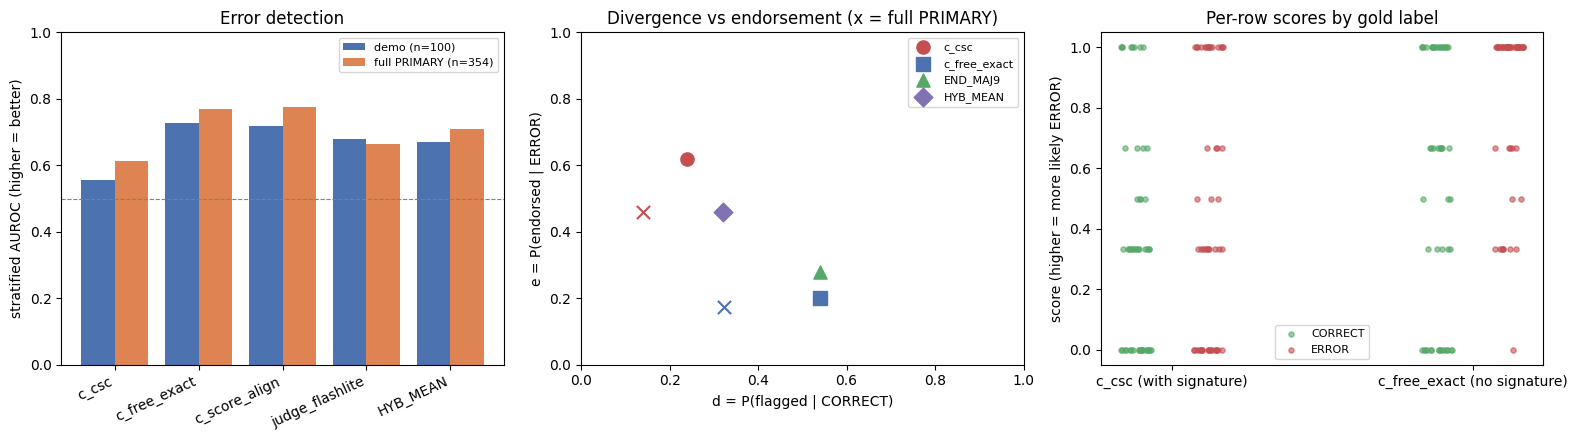

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) strat AUROC per score, demo vs full PRIMARY
cols = ["c_csc", "c_free_exact", "c_score_align", "judge_flashlite", "HYB_MEAN"]
demo_v = [A["strat_auroc"][c] for c in cols]
full_v = [ref["strat_auroc"].get(c, ref["strat_auroc"].get("judge_flashlite_disguised")) for c in cols]
x = np.arange(len(cols))
axes[0].bar(x - 0.2, demo_v, 0.4, label=f"demo (n={A['n']})", color="#4C72B0")
axes[0].bar(x + 0.2, full_v, 0.4, label="full PRIMARY (n=354)", color="#DD8452")
axes[0].axhline(0.5, color="grey", lw=0.8, ls="--")
axes[0].set_xticks(x, cols, rotation=25, ha="right")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("stratified AUROC (higher = better)")
axes[0].set_title("Error detection")
axes[0].legend(fontsize=8)

# (2) e vs d: the anchoring trade-off
for c, mk, colr in (("c_csc", "o", "#C44E52"), ("c_free_exact", "s", "#4C72B0"), ("END_MAJ9", "^", "#55A868"), ("HYB_MEAN", "D", "#8172B2")):
    e_, d_ = A["ed"][c]["e"], A["ed"][c]["d"]
    if e_ is not None and d_ is not None:
        axes[1].scatter(d_, e_, marker=mk, s=90, color=colr, label=c)
for c, colr in (("c_csc", "#C44E52"), ("c_free_exact", "#4C72B0")):
    axes[1].scatter(ref["d"][c], ref["e"][c], marker="x", s=90, color=colr)
axes[1].set_xlabel("d = P(flagged | CORRECT)")
axes[1].set_ylabel("e = P(endorsed | ERROR)")
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)
axes[1].set_title("Divergence vs endorsement (x = full PRIMARY)")
axes[1].legend(fontsize=8)

# (3) score distributions by label
for i, c in enumerate(("c_csc", "c_free_exact")):
    for lab, colr in ((0, "#55A868"), (1, "#C44E52")):
        v = P.loc[P.y == lab, c].values
        axes[2].scatter(np.full(len(v), i + (0.12 if lab else -0.12)) + np.random.default_rng(lab).uniform(-0.05, 0.05, len(v)), v,
                        s=14, alpha=0.6, color=colr, label=("ERROR" if lab else "CORRECT") if i == 0 else None)
axes[2].set_xticks([0, 1], ["c_csc (with signature)", "c_free_exact (no signature)"])
axes[2].set_ylabel("score (higher = more likely ERROR)")
axes[2].set_title("Per-row scores by gold label")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading the plots.**
- **Left:** error detection per score. CSC (`c_csc`) has less signal than signature-free exact consensus (`c_free_exact`) or the 9-peer aligned consensus (`c_score_align`).
- **Middle:** CSC sits lower on d but much higher on e. Giving peers the candidate's symbols removes some vocabulary-driven false alarms, but it also pulls the peers toward the candidate's mistakes, most strongly for wrong-predicate ("meaning rename") and added-condition errors in the full analysis.
- **Right:** many ERROR rows get `c_csc = 0`, because every peer reproduced the error.

The artifact's recommendation for the next iteration is that CSC is not a fix; the rule should fall back to the frozen `c_score_align` + `p_peer_text`.